# Six K562 TSS models: gene-level expression and enhancer–gene linking

Standalone rewrite of the last third of `evaluation_tss.ipynb` with **six** expression models
instead of four, and a renamed 3′ profile model on the E2G side only. Nothing here depends on
`evaluation_tss.ipynb`; the two loader cells (§0 and §8) re-import everything they use.

| name here | run | checkpoint | 6th input channel | window | decoder / loss |
|---|---|---|---|---|---|
| `gene_mask` | `2026-07-27/21-54-24-337889` | `16-val_loss=0.65628` | gene-body mask | asymmetric, TSS at 163840 | `tss`, pools the whole window; `mse_tss` |
| `tss_mask` | `2026-07-27/23-00-33-044232` | `16-val_loss=0.68752` | TSS-neighbourhood mask | TSS-centered (±262144) | `tss`, pools the whole window; `mse_tss` |
| `tss_embeddings` | `2026-07-27/22-39-32-007131` | `16-val_loss=0.84871` | none | TSS-centered (±262144) | `tss`, pools **only the TSS-region** embeddings; `mse_tss` |
| `rna_profile_poisson` | `2026-08-13/16-10-59-441587` | `35-val_loss=0.72645` | gene-body mask | asymmetric, TSS at 163840 | `tss_profile` (count head + bp profile head, `profile_softplus`); `tss_profile_poisson_loss`, `count_weight=1.0`, `poisson_weight=1.0` |
| `rna_profile_tss` | `2026-08-13/16-15-08-293121` | `10-val_loss=1.05699` | TSS-neighbourhood mask | asymmetric, TSS at 163840 | `tss_profile`; `tss_profile_loss`, `count_weight=1.0`, `profile_weight=1e-6` (multinomial) |
| `rna_profile_gene_mask` | `2026-08-13/16-11-23-053119` | `34-val_loss=0.95305` | gene-body mask | asymmetric, TSS at 163840 | `tss_profile`; `tss_profile_loss`, `count_weight=1.0`, `profile_weight=1e-6` (multinomial) |
| `old_poisson_regions` | `2026-08-13/16-16-44-251024` | `07-val_loss=0.13696` | — | 524288 bp, `bin_size=1`, `d_output=2` | bp-resolution stranded 3′ RNA profile (`enformer` decoder, softplus output), `poisson_loss_nan`, trained against `K562_rnaseq_stranded_fixed.npz`. **E2G only** — no scalar expression head, so no `.npz` and no §1–§7. Its score needs the transform correction in §8 — read that first. |

All six expression models were finetuned against the same targets
(`k562_sc_rna_info_cellranger.json`, `log1p` → natural log) on the same 1844-gene test split, so
Pearson/Spearman **and** MSE/MAE are directly comparable. No `log2` ↔ `ln` rescaling is needed
anywhere in §1–§7.

**Caveats to carry through the whole notebook:**

1. **Epoch is not matched.** 16 for the first three, 35 / 10 / 34 for the three profile runs. This
   is neither matched training length nor matched convergence — the comparison is on *test
   metrics*, not on val loss.
2. **Val losses are not comparable across the two families.** The three `mse_tss` runs report a
   pure count loss; `rna_profile_poisson` mixes count MSE with a Poisson profile term and the other
   two mix count MSE with a multinomial term. Only the numbers recomputed below are comparable.
3. **The regression heads are unconstrained** (no `Softplus`, no `log2` — the target is already
   `log1p`), so predictions can go slightly negative. Nothing here clips them.
4. **Three of the four asymmetric-window models are a clean ablation pair set.** `gene_mask` and
   `rna_profile_gene_mask` share inputs, window and pooling and differ only in decoder + loss;
   `rna_profile_poisson` differs from `rna_profile_gene_mask` only in the profile loss (Poisson vs
   multinomial); `rna_profile_tss` differs from `rna_profile_gene_mask` only in which mask channel
   it gets. `tss_mask` uses the *symmetric* window, so it is **not** a clean partner for
   `rna_profile_tss`.

In [1]:
# --- Load the six expression runs -------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, gaussian_kde

MODEL_OUT = "/data1/lesliec/sarthak/data/joint_playground/model_out"

FILES = {
    "gene_mask":             f"{MODEL_OUT}/k562_decima_2.npz",
    "tss_mask":              f"{MODEL_OUT}/k562_tssmask.npz",
    "tss_embeddings":        f"{MODEL_OUT}/k562_finetune_2.npz",
    "rna_profile_poisson":   f"{MODEL_OUT}/k562_tss_sc_rna_poisson_ep35.npz",
    "rna_profile_tss":       f"{MODEL_OUT}/k562_tss_sc_rna_profile_tss_fixed_ep10.npz",
    "rna_profile_gene_mask": f"{MODEL_OUT}/k562_tss_sc_rna_profile_decima_fixed_ep34.npz",
}

COLORS = {
    "gene_mask":             "#ff7f0e",
    "tss_mask":              "#d62728",
    "tss_embeddings":        "#9467bd",
    "rna_profile_poisson":   "#17becf",
    "rna_profile_tss":       "#2ca02c",
    "rna_profile_gene_mask": "#1f77b4",
    "old_poisson_regions":   "#8c564b",   # E2G only, used from section 8 on
}
NAMES = list(FILES)

runs = {}
for name, path in FILES.items():
    d = np.load(path, allow_pickle=True)
    runs[name] = {
        "genes": d["genes"],
        "preds": d["preds"].ravel(),
        "targets": d["targets"],
        "chroms": d["chroms"],
        "strands": d["strands"],
        "ckpt": str(d["ckpt_path"]),
        "tss_json": str(d["tss_json_file"]),
    }
    print(f"{name:22s} n={len(d['genes']):5d}  "
          f"targets={str(d['tss_json_file']).split('/')[-1]}  "
          f"ckpt={'/'.join(str(d['ckpt_path']).split('/')[-3:])}")

gene_mask              n= 1844  targets=k562_sc_rna_info_cellranger.json  ckpt=21-54-24-337889/checkpoints/16-val_loss=0.65628.ckpt
tss_mask               n= 1844  targets=k562_sc_rna_info_cellranger.json  ckpt=23-00-33-044232/checkpoints/16-val_loss=0.68752.ckpt
tss_embeddings         n= 1844  targets=k562_sc_rna_info_cellranger.json  ckpt=22-39-32-007131/checkpoints/16-val_loss=0.84871.ckpt
rna_profile_poisson    n= 1844  targets=k562_sc_rna_info_cellranger.json  ckpt=16-10-59-441587/checkpoints/35-val_loss=0.72645.ckpt
rna_profile_tss        n= 1844  targets=k562_sc_rna_info_cellranger.json  ckpt=16-15-08-293121/checkpoints/10-val_loss=1.05699.ckpt
rna_profile_gene_mask  n= 1844  targets=k562_sc_rna_info_cellranger.json  ckpt=16-11-23-053119/checkpoints/34-val_loss=0.95305.ckpt


In [2]:
# Align on the shared gene set. All six used k562_sc_rna_info_cellranger.json and the same split,
# so this is expected to be all 1844 genes; the intersection is kept anyway so the cell stays
# correct if a future run uses a different gene set.
common = sorted(set.intersection(*[set(r["genes"].tolist()) for r in runs.values()]))
print(f"{len(common)} genes shared across the six runs")

for name, r in runs.items():
    idx_by_gene = {g: i for i, g in enumerate(r["genes"].tolist())}
    order = [idx_by_gene[g] for g in common]
    r["p"] = r["preds"][order]
    r["t"] = r["targets"][order]
    r["chrom"] = r["chroms"][order]
    r["strand"] = r["strands"][order]

# One shared target json means the aligned target vectors must be identical -- that is what
# licenses comparing MSE/MAE across models, so assert it rather than assume it.
ref_t = runs[NAMES[0]]["t"]
for name in NAMES[1:]:
    assert np.allclose(runs[name]["t"], ref_t), f"{name}: targets differ from {NAMES[0]}"
print("targets identical across all six runs -> MSE/MAE are directly comparable")


def metrics(p, t):
    return {
        "pearson": float(np.corrcoef(p, t)[0, 1]),
        "spearman": float(spearmanr(p, t).statistic),
        "mse": float(((p - t) ** 2).mean()),
        "mae": float(np.abs(p - t).mean()),
    }


stats_ = {name: metrics(r["p"], r["t"]) for name, r in runs.items()}
print(f"\n{'run':24s}{'pearson':>10s}{'spearman':>10s}{'MSE':>10s}{'MAE':>10s}")
for name in NAMES:
    s = stats_[name]
    print(f"{name:24s}{s['pearson']:10.4f}{s['spearman']:10.4f}{s['mse']:10.4f}{s['mae']:10.4f}")

# Per-strand split: rc_strand reverse-complements minus-strand genes, so a gap between the two
# columns would point at the flip (coordinate mapping / mask alignment) rather than the model.
print(f"\n{'run':24s}{'r (+)':>9s}{'r (-)':>9s}{'n +':>7s}{'n -':>7s}")
for name in NAMES:
    r = runs[name]
    rs = [float(np.corrcoef(r["p"][r["strand"] == s], r["t"][r["strand"] == s])[0, 1])
          for s in (1, -1)]
    print(f"{name:24s}{rs[0]:9.4f}{rs[1]:9.4f}"
          f"{int((r['strand'] == 1).sum()):7d}{int((r['strand'] == -1).sum()):7d}")

print(f"\n{'run':24s}{'pred min':>10s}{'pred max':>10s}{'pred std':>10s}{'target std':>12s}")
for name in NAMES:
    p = runs[name]["p"]
    print(f"{name:24s}{p.min():10.3f}{p.max():10.3f}{p.std():10.3f}{ref_t.std():12.3f}")

1844 genes shared across the six runs
targets identical across all six runs -> MSE/MAE are directly comparable

run                        pearson  spearman       MSE       MAE
gene_mask                   0.9057    0.9073    0.6974    0.5683
tss_mask                    0.9092    0.8978    0.6350    0.5598
tss_embeddings              0.8912    0.8729    0.7567    0.6192
rna_profile_poisson         0.9122    0.9109    0.6512    0.5476
rna_profile_tss             0.9088    0.9017    0.6343    0.5535
rna_profile_gene_mask       0.9058    0.9021    0.6604    0.5583

run                         r (+)    r (-)    n +    n -
gene_mask                  0.9068   0.9047    916    928
tss_mask                   0.9084   0.9101    916    928
tss_embeddings             0.8876   0.8948    916    928
rna_profile_poisson        0.9105   0.9139    916    928
rna_profile_tss            0.9043   0.9133    916    928
rna_profile_gene_mask      0.9025   0.9091    916    928

run                       pred m


## 1. Metrics per run

Same targets, same genes for all six. Epoch is *not* matched (16 / 16 / 16 / 35 / 10 / 34).

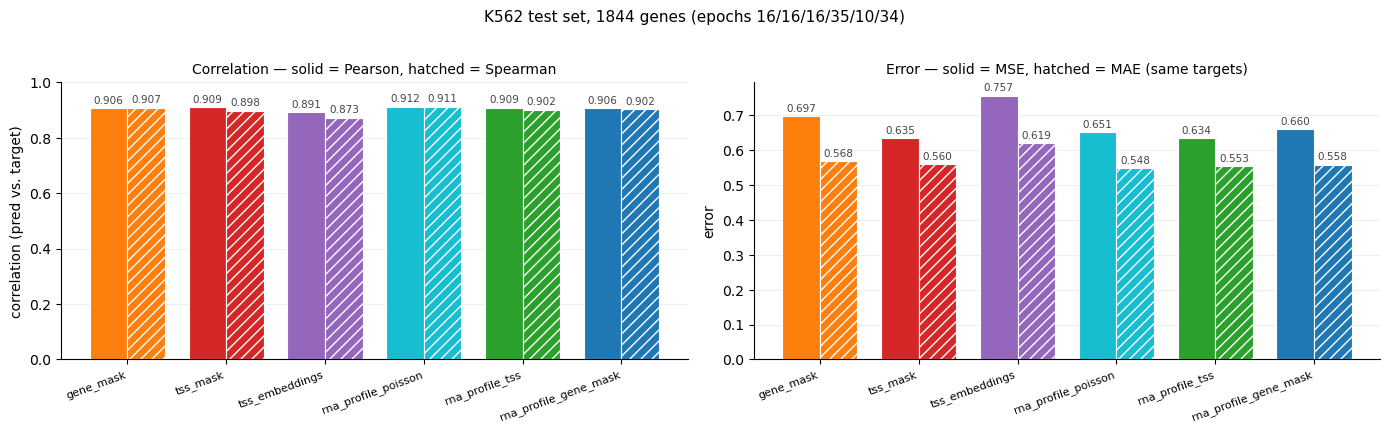

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
x = np.arange(len(NAMES))
w = 0.38

ax = axes[0]
for off, key, hatch in [(-w / 2, "pearson", None), (w / 2, "spearman", "///")]:
    vals = [stats_[n][key] for n in NAMES]
    ax.bar(x + off, vals, w, color=[COLORS[n] for n in NAMES],
           hatch=hatch, edgecolor="white", linewidth=0.8)
    for xi, v in zip(x + off, vals):
        ax.text(xi, v + 0.012, f"{v:.3f}", ha="center", va="bottom", fontsize=7.5, color="#444")
ax.set_ylim(0, 1.0)
ax.set_ylabel("correlation (pred vs. target)")
ax.set_title("Correlation — solid = Pearson, hatched = Spearman", fontsize=10)

ax = axes[1]
for off, key, hatch in [(-w / 2, "mse", None), (w / 2, "mae", "///")]:
    vals = [stats_[n][key] for n in NAMES]
    ax.bar(x + off, vals, w, color=[COLORS[n] for n in NAMES],
           hatch=hatch, edgecolor="white", linewidth=0.8)
    for xi, v in zip(x + off, vals):
        ax.text(xi, v + 0.008, f"{v:.3f}", ha="center", va="bottom", fontsize=7.5, color="#444")
ax.set_ylabel("error")
ax.set_title("Error — solid = MSE, hatched = MAE (same targets)", fontsize=10)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(NAMES, rotation=20, ha="right", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)

fig.suptitle(f"K562 test set, {len(common)} genes (epochs 16/16/16/35/10/34)", fontsize=11, y=1.02)
fig.tight_layout()
plt.show()


## 2. Distribution of predicted and observed values

Target drawn once as a filled gray reference — it is identical for all six. The right panel is the
residual distribution: a shift off zero is bias, a wide spread is variance.

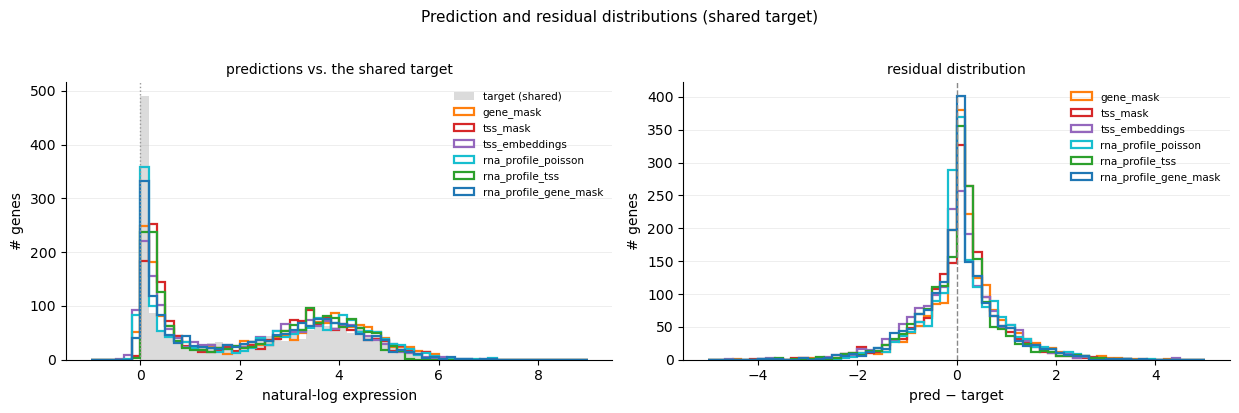

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0))
bins = np.linspace(-1, 9, 61)

ax = axes[0]
# target drawn once as a filled reference: it is identical for all six models
ax.hist(ref_t, bins=bins, color="#cccccc", alpha=0.7, label="target (shared)", zorder=0)
for name in NAMES:
    ax.hist(runs[name]["p"], bins=bins, histtype="step", linewidth=1.6,
            color=COLORS[name], label=name)
ax.axvline(0, color="#999", linestyle=":", linewidth=1.0)
ax.set_xlabel("natural-log expression")
ax.set_ylabel("# genes")
ax.set_title("predictions vs. the shared target", fontsize=10)
ax.legend(frameon=False, fontsize=7.5)

ax = axes[1]
for name in NAMES:
    ax.hist(runs[name]["p"] - ref_t, bins=np.linspace(-5, 5, 61), histtype="step",
            linewidth=1.6, color=COLORS[name], label=name)
ax.axvline(0, color="#888", linestyle="--", linewidth=1.0)
ax.set_xlabel("pred − target")
ax.set_ylabel("# genes")
ax.set_title("residual distribution", fontsize=10)
ax.legend(frameon=False, fontsize=7.5)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)

fig.suptitle("Prediction and residual distributions (shared target)", fontsize=11, y=1.02)
fig.tight_layout()
plt.show()

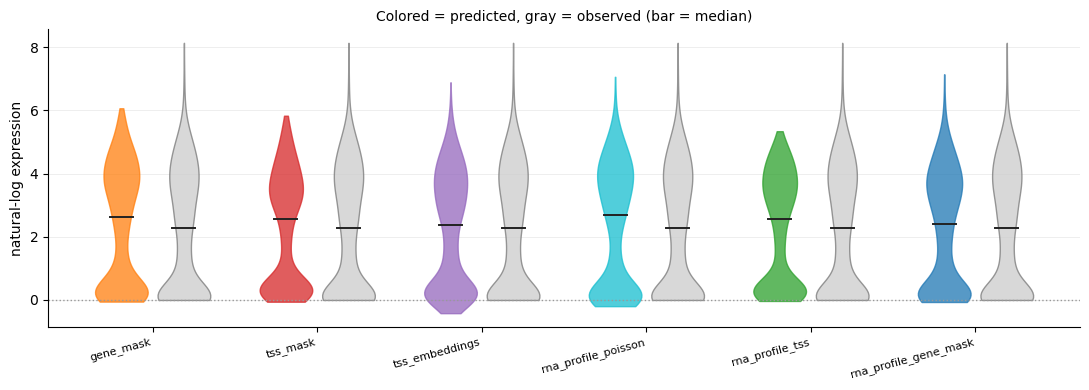

In [5]:
# Same information as paired violins: for each run, predicted vs. observed spread.
fig, ax = plt.subplots(figsize=(11, 4))

positions, data, face, edge = [], [], [], []
for i, name in enumerate(NAMES):
    positions += [i - 0.19, i + 0.19]
    data += [runs[name]["p"], runs[name]["t"]]
    face += [COLORS[name], "#cccccc"]
    edge += [COLORS[name], "#777777"]

parts = ax.violinplot(data, positions=positions, widths=0.32, showextrema=False)
for body, fc, ec in zip(parts["bodies"], face, edge):
    body.set_facecolor(fc)
    body.set_edgecolor(ec)
    body.set_alpha(0.75)
    body.set_linewidth(1.0)

for pos, arr in zip(positions, data):
    ax.plot([pos - 0.07, pos + 0.07], [np.median(arr)] * 2, color="#222", linewidth=1.4)

ax.axhline(0, color="#999", linestyle=":", linewidth=1.0)
ax.set_xticks(np.arange(len(NAMES)))
ax.set_xticklabels(NAMES, rotation=15, ha="right", fontsize=8)
ax.set_ylabel("natural-log expression")
ax.set_title("Colored = predicted, gray = observed (bar = median)", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()


## 3. Predicted vs. observed, per run

Density-colored scatter; dashed line is `y = x`. All six panels share the same x axis (the common
target), so they are overlayable by eye.

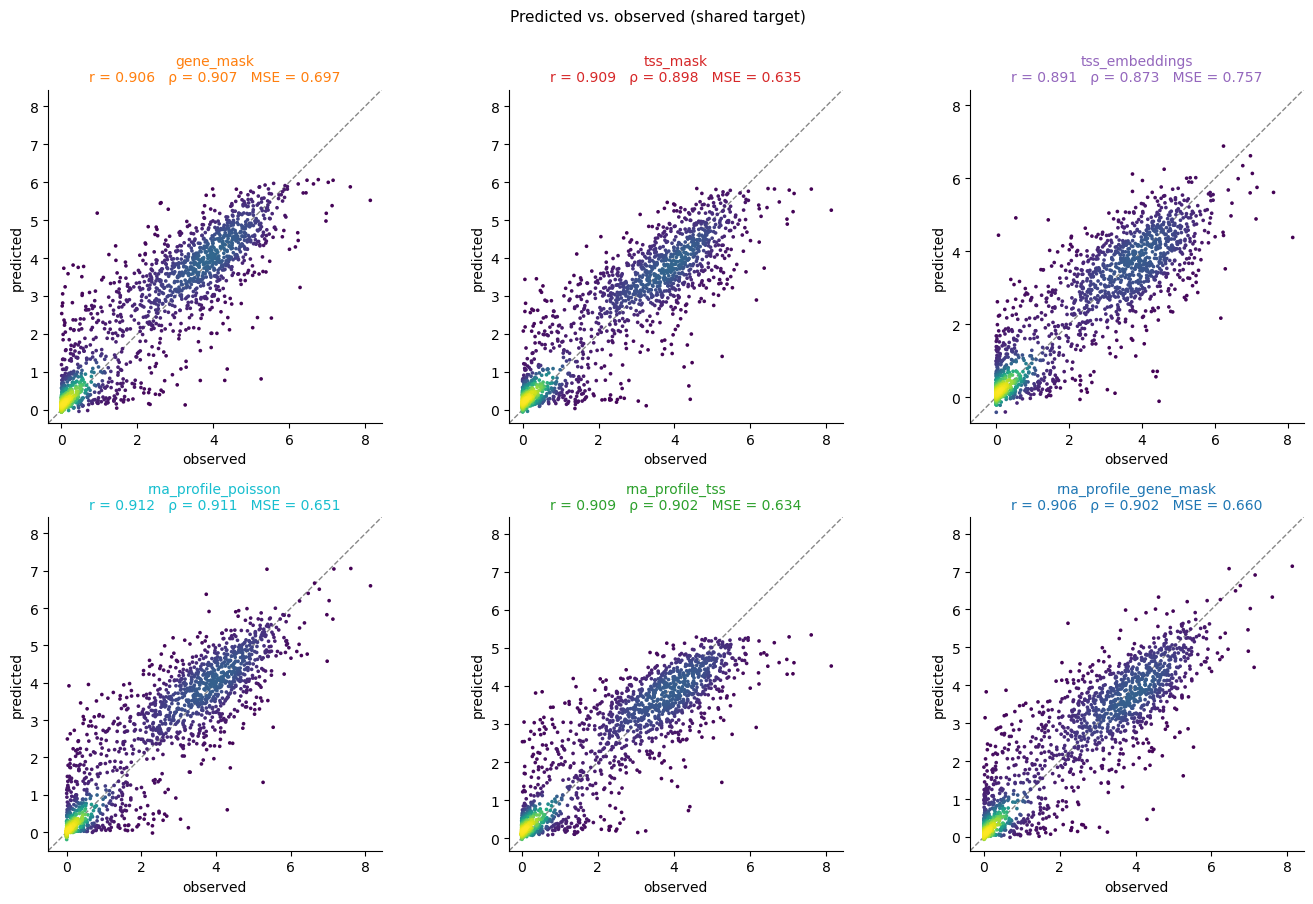

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for ax, name in zip(axes.ravel(), NAMES):
    t, p = runs[name]["t"], runs[name]["p"]
    dens = gaussian_kde(np.vstack([t, p]))(np.vstack([t, p]))
    order = dens.argsort()  # draw dense points last so they are not buried
    ax.scatter(t[order], p[order], c=dens[order], s=7, cmap="viridis", linewidths=0)

    lim = (min(t.min(), p.min()) - 0.3, max(t.max(), p.max()) + 0.3)
    ax.plot(lim, lim, "--", color="#888", linewidth=1.0, zorder=0)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect("equal")

    s = stats_[name]
    ax.set_title(f"{name}\nr = {s['pearson']:.3f}   ρ = {s['spearman']:.3f}   MSE = {s['mse']:.3f}",
                 fontsize=10, color=COLORS[name])
    ax.set_xlabel("observed")
    ax.set_ylabel("predicted")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Predicted vs. observed (shared target)", fontsize=11, y=1.0)
fig.tight_layout()
plt.show()


## 4. Model vs. model

Six models make fifteen pairs, too many to read as a scatter grid, so the pairwise agreement goes
in a matrix (Pearson r below the diagonal is the same as above — it is drawn symmetric, with
Spearman ρ in the second panel). All six are in natural log, so no rescaling is needed.

The three scatters after it are the pairs that isolate one design choice each — see caveat 4 at
the top.

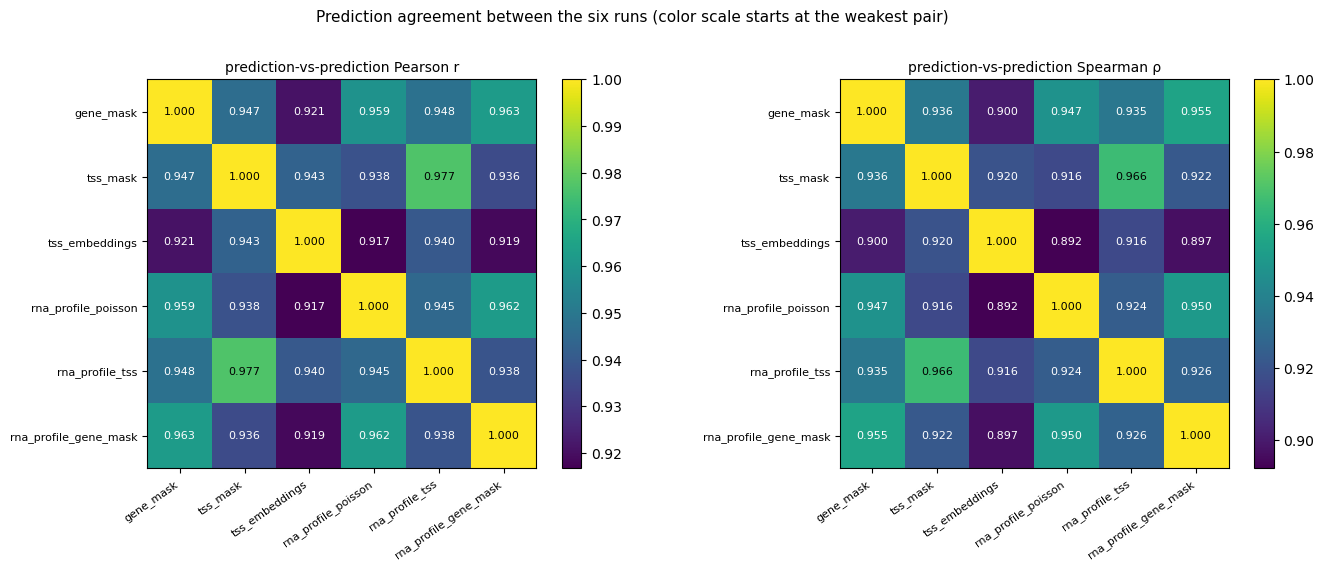

In [7]:
# Pairwise prediction agreement as a matrix: 15 pairs is too many scatter panels to read.
P = np.vstack([runs[n]["p"] for n in NAMES])
r_mat = np.corrcoef(P)
rho_mat = spearmanr(P, axis=1).statistic

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
for ax, M, label in [(axes[0], r_mat, "Pearson r"), (axes[1], rho_mat, "Spearman ρ")]:
    off_diag = M[~np.eye(len(NAMES), dtype=bool)]
    im = ax.imshow(M, cmap="viridis", vmin=off_diag.min(), vmax=1.0)
    for i in range(len(NAMES)):
        for j in range(len(NAMES)):
            ax.text(j, i, f"{M[i, j]:.3f}", ha="center", va="center", fontsize=8,
                    color="white" if M[i, j] < off_diag.min() + 0.6 * (1 - off_diag.min())
                    else "black")
    ax.set_xticks(np.arange(len(NAMES)))
    ax.set_xticklabels(NAMES, rotation=35, ha="right", fontsize=8)
    ax.set_yticks(np.arange(len(NAMES)))
    ax.set_yticklabels(NAMES, fontsize=8)
    ax.set_title(f"prediction-vs-prediction {label}", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle("Prediction agreement between the six runs (color scale starts at the weakest pair)",
             fontsize=11, y=1.01)
fig.tight_layout()
plt.show()

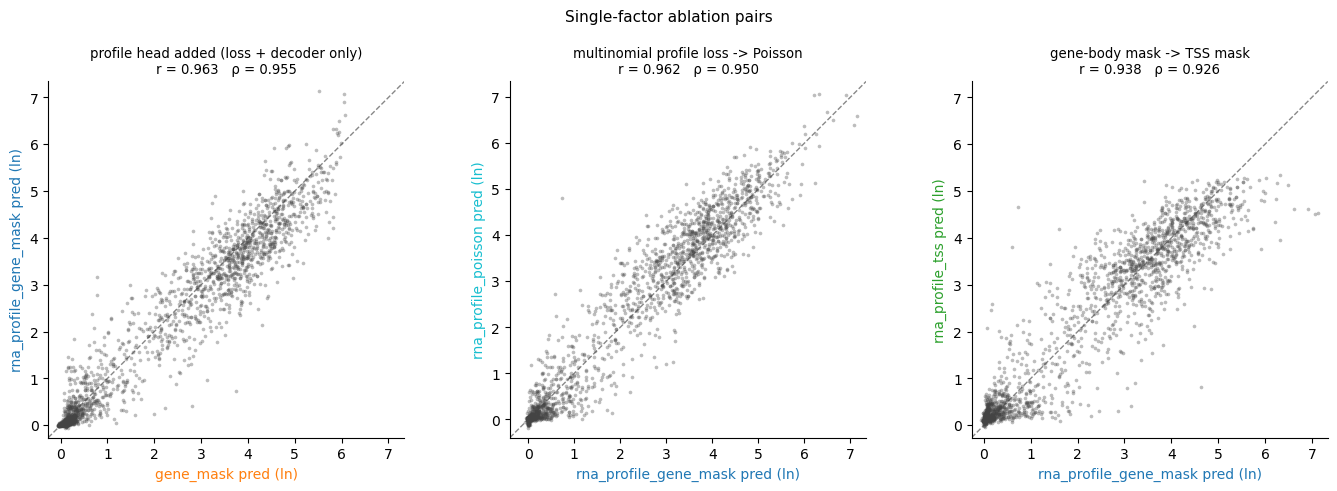

In [8]:
# The three pairs that isolate a single design choice (caveat 4 at the top of the notebook).
ABLATION_PAIRS = [
    ("gene_mask", "rna_profile_gene_mask", "profile head added (loss + decoder only)"),
    ("rna_profile_gene_mask", "rna_profile_poisson", "multinomial profile loss -> Poisson"),
    ("rna_profile_gene_mask", "rna_profile_tss", "gene-body mask -> TSS mask"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
for ax, (a, b, what) in zip(axes, ABLATION_PAIRS):
    pa, pb = runs[a]["p"], runs[b]["p"]
    ax.scatter(pa, pb, s=7, alpha=0.35, color="#444", linewidths=0)

    lim = (min(pa.min(), pb.min()) - 0.2, max(pa.max(), pb.max()) + 0.2)
    ax.plot(lim, lim, "--", color="#888", linewidth=1.0, zorder=0)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect("equal")

    r = np.corrcoef(pa, pb)[0, 1]
    rho = spearmanr(pa, pb).statistic
    ax.set_title(f"{what}\nr = {r:.3f}   ρ = {rho:.3f}", fontsize=9.5)
    ax.set_xlabel(f"{a} pred (ln)", color=COLORS[a])
    ax.set_ylabel(f"{b} pred (ln)", color=COLORS[b])
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Single-factor ablation pairs", fontsize=11, y=1.02)
fig.tight_layout()
plt.show()


### 4b. Per-gene head-to-head

For each gene, which model is closest? A model can win on aggregate MSE while losing on most
individual genes (a few large misses dominate the mean), so the win rate and the aggregate metric
answer different questions.

share of genes where each model has the smallest |error| of the six:
  gene_mask                 15.1%
  tss_mask                  12.3%
  tss_embeddings            16.2%
  rna_profile_poisson       24.2%
  rna_profile_tss           13.6%
  rna_profile_gene_mask     18.7%

pairwise win rate (row model closer than column model, per gene):
                                   gene_mask          tss_mask    tss_embeddings  rna_profile_pois   rna_profile_tss  rna_profile_gene
gene_mask                                               55.0%             56.2%             45.3%             53.2%             46.7% 
tss_mask                              45.0%                               52.3%             43.5%             49.8%             44.8% 
tss_embeddings                        43.8%             47.7%                               40.9%             46.1%             43.8% 
rna_profile_poisson                   54.7%             56.5%             59.1%                               56.6%     

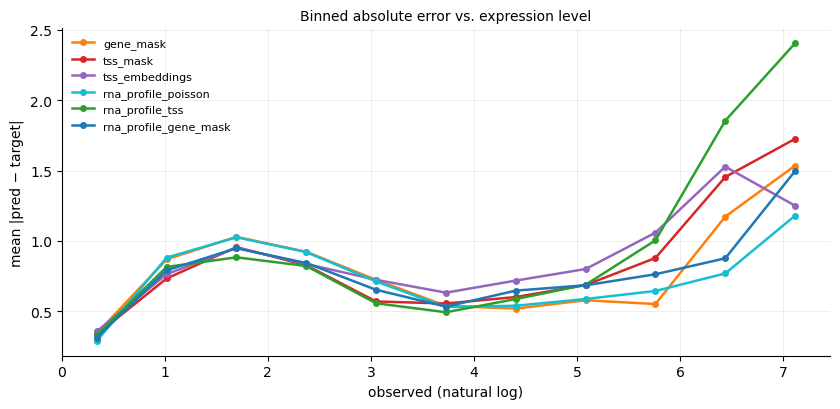

In [9]:
abs_err = {n: np.abs(runs[n]["p"] - ref_t) for n in NAMES}
best = np.vstack([abs_err[n] for n in NAMES]).argmin(axis=0)

print("share of genes where each model has the smallest |error| of the six:")
for i, n in enumerate(NAMES):
    print(f"  {n:24s}{(best == i).mean():7.1%}")

print("\npairwise win rate (row model closer than column model, per gene):")
print(f"{'':26s}" + "".join(f"{n[:16]:>18s}" for n in NAMES))
for a in NAMES:
    row = ["".ljust(18) if a == b else f"{(abs_err[a] < abs_err[b]).mean():17.1%} "
           for b in NAMES]
    print(f"{a:26s}" + "".join(row))

# Where in the expression range each model wins or loses -- the aggregate MSE hides this.
fig, ax = plt.subplots(figsize=(8.5, 4.2))
edges = np.linspace(ref_t.min(), ref_t.max(), 13)
centers = 0.5 * (edges[:-1] + edges[1:])
for n in NAMES:
    means = [abs_err[n][(ref_t >= lo) & (ref_t < hi)].mean()
             if ((ref_t >= lo) & (ref_t < hi)).sum() > 3 else np.nan
             for lo, hi in zip(edges[:-1], edges[1:])]
    ax.plot(centers, means, color=COLORS[n], linewidth=1.8, marker="o", markersize=4, label=n)
ax.set_xlabel("observed (natural log)")
ax.set_ylabel("mean |pred − target|")
ax.set_title("Binned absolute error vs. expression level", fontsize=10)
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()


## 5. Per-chromosome correlation

Checks whether any single test chromosome drives the overall numbers.

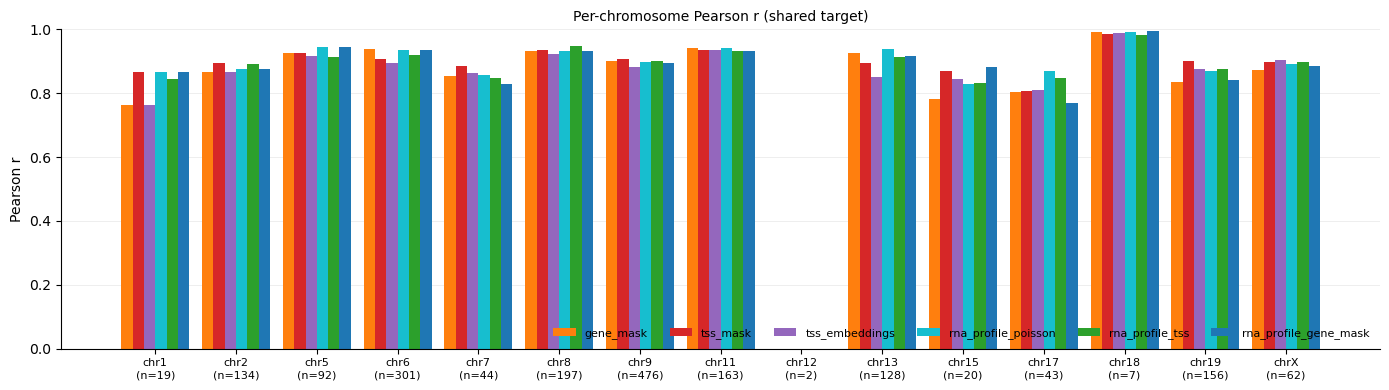

In [10]:
chroms = sorted(set(runs[NAMES[0]]["chrom"].tolist()),
                key=lambda c: (c == "chrX", int(c[3:]) if c[3:].isdigit() else 99))
counts = [int((runs[NAMES[0]]["chrom"] == c).sum()) for c in chroms]

fig, ax = plt.subplots(figsize=(14, 4.0))
w = 0.14
for i, name in enumerate(NAMES):
    r = runs[name]
    vals = []
    for c in chroms:
        m = r["chrom"] == c
        vals.append(float(np.corrcoef(r["p"][m], r["t"][m])[0, 1]) if m.sum() > 2 else np.nan)
    ax.bar(np.arange(len(chroms)) + (i - 2.5) * w, vals, w, color=COLORS[name], label=name)

ax.set_xticks(np.arange(len(chroms)))
ax.set_xticklabels([f"{c}\n(n={m})" for c, m in zip(chroms, counts)], fontsize=8)
ax.set_ylabel("Pearson r")
ax.set_ylim(0, 1.0)
ax.legend(frameon=False, fontsize=8, ncol=6, loc="lower right")
ax.set_title("Per-chromosome Pearson r (shared target)", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()


## 6. Where the error lives

Signed residual (`pred − target`) against observed expression. A downward trend means the model
over-predicts silent genes and under-predicts highly expressed ones — regression toward the mean.

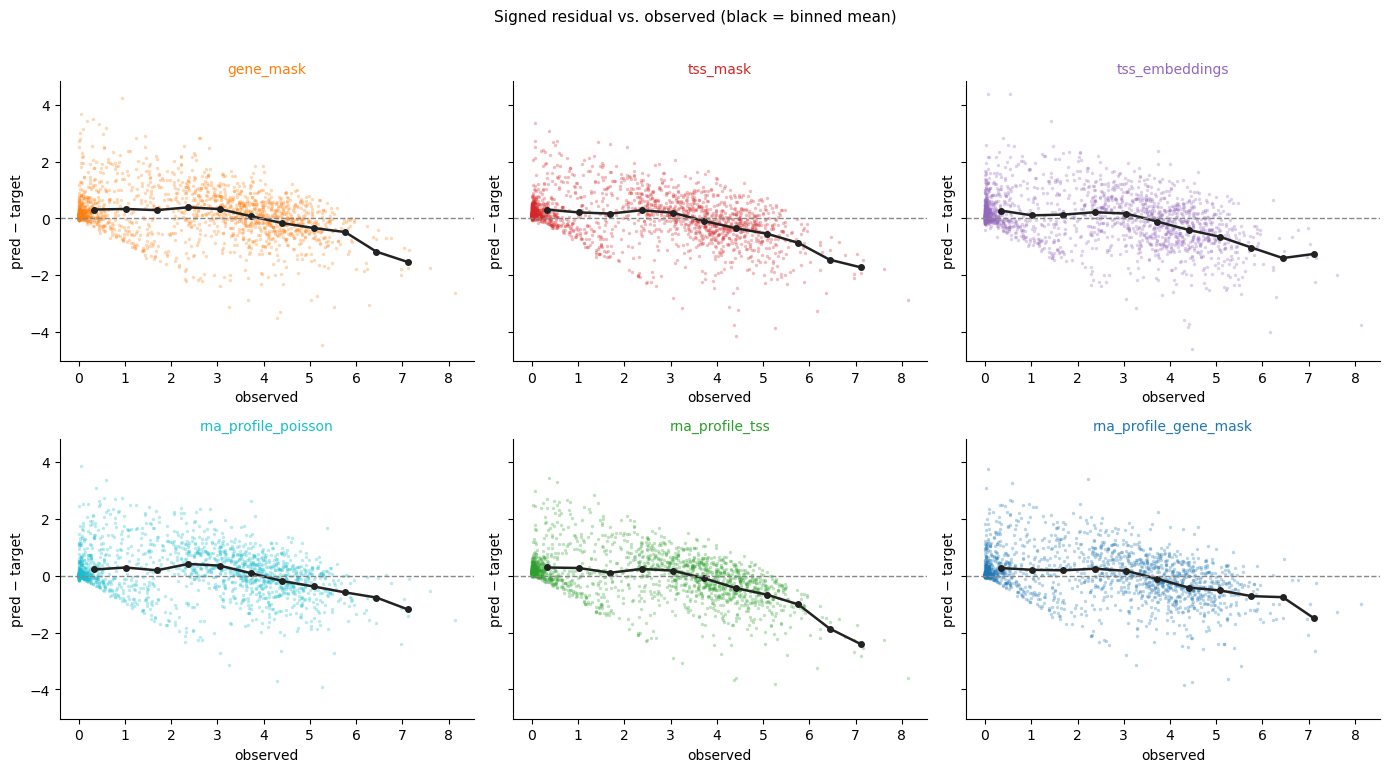

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7.6), sharey=True)

for ax, name in zip(axes.ravel(), NAMES):
    t, p = runs[name]["t"], runs[name]["p"]
    resid = p - t
    ax.scatter(t, resid, s=6, alpha=0.3, color=COLORS[name], linewidths=0)

    # binned mean residual, to make the trend readable through the point cloud
    edges = np.linspace(t.min(), t.max(), 13)
    centers = 0.5 * (edges[:-1] + edges[1:])
    means = [resid[(t >= lo) & (t < hi)].mean() if ((t >= lo) & (t < hi)).sum() > 3 else np.nan
             for lo, hi in zip(edges[:-1], edges[1:])]
    ax.plot(centers, means, color="#222", linewidth=1.8, marker="o", markersize=4)

    ax.axhline(0, color="#888", linestyle="--", linewidth=1.0)
    ax.set_xlabel("observed")
    ax.set_ylabel("pred − target")
    ax.set_title(name, fontsize=10, color=COLORS[name])
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Signed residual vs. observed (black = binned mean)", fontsize=11, y=1.01)
fig.tight_layout()
plt.show()


## 7. Rank profile

Genes sorted by observed expression with the prediction overlaid. The ordering is identical across
panels, so the traces can be compared position by position.

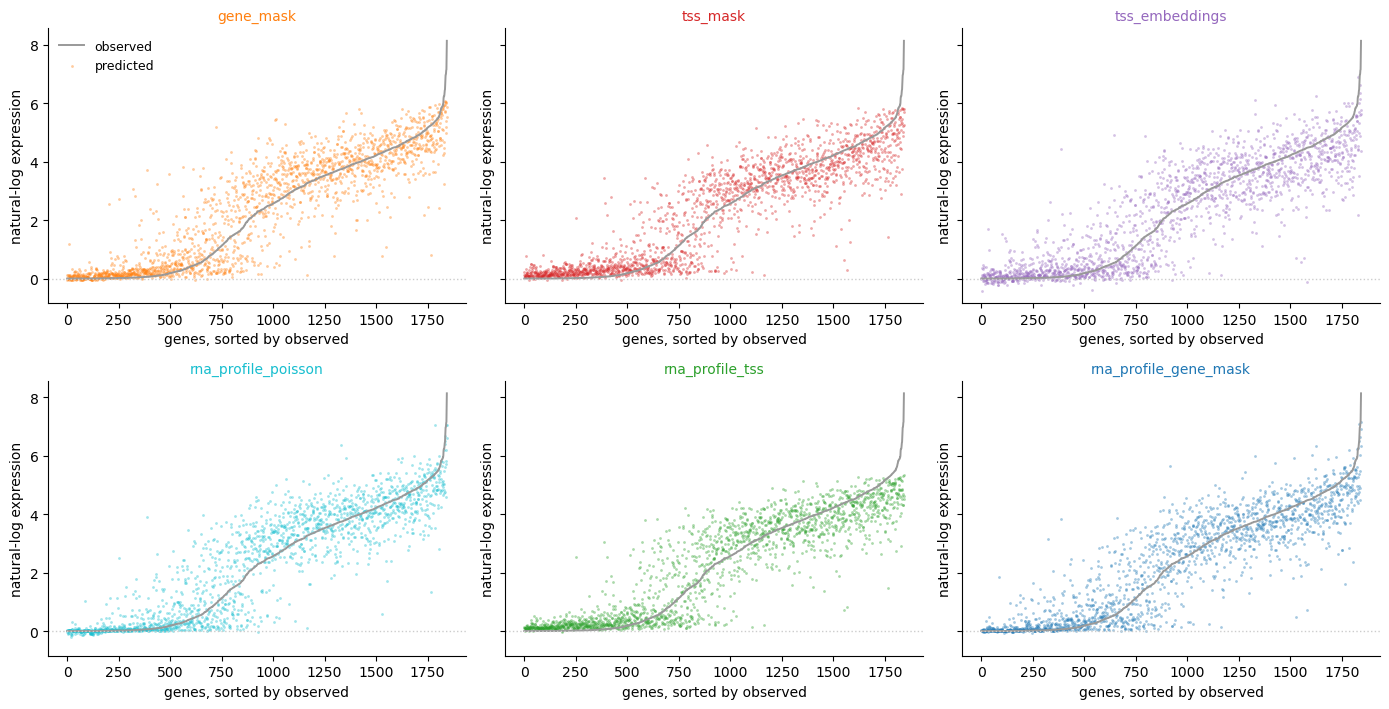

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7.2), sharey=True)

for ax, name in zip(axes.ravel(), NAMES):
    t, p = runs[name]["t"], runs[name]["p"]
    order = np.argsort(t)
    xs = np.arange(len(order))
    ax.plot(xs, t[order], color="#999", linewidth=1.4, label="observed")
    ax.scatter(xs, p[order], s=4, alpha=0.4, color=COLORS[name], linewidths=0, label="predicted")
    ax.axhline(0, color="#ccc", linestyle=":", linewidth=1.0)
    ax.set_xlabel("genes, sorted by observed")
    ax.set_ylabel("natural-log expression")
    ax.set_title(name, fontsize=10, color=COLORS[name])
    ax.spines[["top", "right"]].set_visible(False)

axes.ravel()[0].legend(frameon=False, fontsize=9, loc="upper left")
fig.tight_layout()
plt.show()


### Reference — expression metrics from the eval job logs

For cross-checking the cells above against the runs themselves. The three epoch-16 rows come from
`tss_eval_5782782_*`, the three profile rows from `tss_eval_9395356_*`; §1 recomputes all of them
from the `.npz` files, so they should match exactly.

| model | Pearson r | Spearman ρ | MSE | r (+) / r (−) |
|---|---|---|---|---|
| `gene_mask` | 0.9057 | 0.9073 | 0.6974 | — |
| `tss_mask` | 0.9092 | 0.8978 | 0.6350 | — |
| `tss_embeddings` | 0.8912 | 0.8729 | 0.7567 | — |
| `rna_profile_poisson` | 0.9122 | 0.9109 | 0.6512 | 0.9105 / 0.9139 |
| `rna_profile_tss` | 0.9088 | 0.9017 | 0.6343 | 0.9043 / 0.9133 |
| `rna_profile_gene_mask` | 0.9058 | 0.9021 | 0.6604 | 0.9025 / 0.9091 |

Fill in the written takeaways after running — the ablation pairs to read are `gene_mask` vs.
`rna_profile_gene_mask` (does the profile head cost count accuracy?), `rna_profile_gene_mask` vs.
`rna_profile_poisson` (Poisson vs. multinomial profile term), and `rna_profile_gene_mask` vs.
`rna_profile_tss` (which mask channel), keeping the epoch mismatch in view for all three.

## 8. Enhancer–gene linking (ENCODE CRISPR benchmark)

The six expression models plus `old_poisson_regions` on the ENCODE CRISPR benchmark. All seven run
the same experiment — divide the accessibility track by 100 over the CRISPR element ± 100 bp
(`--scale_factor 100 --dist_additional_mask 100`) and read the change in predicted expression — but
the readout differs:

- the six TSS models give two scalars per pair, `outputs[:, 0]` (unperturbed) and `outputs[:, 1]`
  (perturbed), and the score is their difference in natural log;
- `old_poisson_regions` gives *summed bp-resolution profile* before/after, over three genomic
  windows (`body`, `tp` = 3′-terminal 10 kb, `tss` = TSS ± 2 kb) and both strands, and the score is
  `log2fc_raw_{window}_{strand}`.

The per-model figures below come to nine, not seven: the 3′ model gets one distance-stratified
figure for each of its three aggregation windows (`tp`, `tss`, `body`, sense strand), because they
do not behave alike. The headline 3′ score everywhere else is **`log2fc_sqrt_tp_sense`** — the 3′-terminal window
`e2g_3prime.py` argues should be right for 3′ RNA-seq data, which piles reads at the last exon /
polyA site, scored in the model's own output space (see the transform note below). §8a tests both
the window and the output space against the alternatives rather than assuming either, with the
antisense strand as a control that *should* be much less responsive if the model has learned
strand-specific 3′ transcription.

**Mechanical points, all of them load-bearing:**

1. **One `gs_df` for the six TSS models** (10306 pairs): they share
   `k562_sc_rna_info_cellranger.json`, so the pair set, its order and the labels are identical.
2. **`in_context` still differs by window geometry.** The four asymmetric-window models
   (`gene_mask` and the three `rna_profile_*`) get 3914 pairs; the two TSS-centered models
   (`tss_mask`, `tss_embeddings`) get 3957. Both windows are 524288 bp, but the asymmetric one is
   163840 upstream / 360448 downstream and so covers slightly fewer CRISPR elements. The cell below
   asserts that the four asymmetric masks are bit-identical — a free determinism check on the E2G
   harness.
3. **`old_poisson_regions` sits on a different pair set.** `evals/e2g_3prime.py:182` builds `gs_df`
   from `k562_bulk_rna_info.json`, giving **10280** pairs — a strict subset of the 10306. Its rows
   are grouped by `ensg_id` rather than left in input order, so they are re-sorted by `row_idx`
   first; the cell below asserts that this reproduces the bulk-json `gs_df` order exactly.
4. **The `sqrt_*` columns are the ones read here, not `raw_*` — this is the opposite of what
   `e2g_3prime.py`'s header comment says, and the reason is a target-transform change.** See the
   dedicated subsection below; the short version is that this checkpoint was trained against
   `K562_rnaseq_stranded_fixed.npz`, whose stored target is `sqrt(1+x) - 1`, so the script's
   `clip(pred**2 - 1, 0, None)` is the inverse of the *old* transform and `raw_*` is wrong for this
   run. Under the fixed transform the no-signal baseline is 0, which is exactly the objection that
   made `raw_*` necessary in the first place, so `sqrt_*` is now the clean column.
5. **The `tp` columns are NaN on 45 rows** whose 3′-terminal window falls entirely outside the
   524288 bp input window (`reduce_profile`'s `hi <= lo` branch), 19 of them in context — both
   spaces, `raw` and `sqrt` alike. Those rows drop out of every panel that uses a `tp` score, and
   out of *all seven* curves in the head-to-head panels so the models stay on an identical subset
   there.
6. **`DistanceToTSS`** is left-merged from the rE2G table (an inner merge returns 10411 rows, which
   matches no model's `gs_df`).
7. Out-of-context pairs are not exactly zero for any model — float noise sits some five to six
   orders of magnitude below real signal — so `in_context` always comes from the stored
   mask/column, never from `score != 0`.

### The 3′ model's output space — why `raw_*` is wrong for this checkpoint

`e2g_3prime.py` reduces the bp-resolution profile in two spaces (`reduce_profile`, `:237-255`):

```python
raw  = np.clip(pred.astype(np.float64) ** 2 - 1.0, 0, None).sum()   # meant to undo sqrt(1+x)
sqrt = pred.sum()                                                    # the model's own space
```

`raw_*` inverts **`sqrt(1+x)`**. That was the transform in `bigwig_to_npz.py:58`, and it is the
right inverse for `k562_3prime_e2g.csv` (ckpt `2026-08-05/13-39-56`, trained on
`K562_rnaseq_stranded.npz`). But this checkpoint — `2026-08-13/16-16-44`, the one behind
`k562_3prime_fixed_e2g_ep7.csv` — was trained on `K562_rnaseq_stranded_fixed.npz`, which
`make_fixed_npz.py` wrote as **`sqrt(1+x) - 1`** (the Decima-style `-1 + (1+x)^p`; the `-1` had been
dropped, leaving 93% of chr21 pinned at a constant 1.0 floor). The correct inverse for this run is
therefore

$$x = (\hat{y}+1)^2 - 1 = \hat{y}^2 + 2\hat{y}$$

and since the decoder ends in a softplus (`decoders.py:471`) every $\hat{y} > 0$, so nothing clips.

**What that costs, and what is recoverable from the csv.** The saved columns are
$A=\sum_{\hat y>1}(\hat y^2-1)$ (clipped!) and $S=\sum \hat y$, over each window of $N$ bp:

- $S$ is exact, so **`log2fc_sqrt_*` is exactly right** — and with a zero baseline under the fixed
  transform it is a legitimate variance-stabilized aggregate, not the baseline-polluted quantity the
  script's header warns about. This is what §8 uses.
- The count-space sum needs $\sum \hat y^2 = A + M + \sum_{\hat y \le 1}\hat y^2$ where $M$ counts
  the bp above 1 — the clip destroyed both terms, so it is **not exactly recoverable**. It is
  bracketed, though: $\sum \hat y^2 \in [A,\ A+N]$, giving
  $\widehat{\text{count}} \in [A + 2S,\ A + N + 2S]$. The next cell recomputes $N$ per window
  (exactly reproducing the script's `windows_for`, checked against the stored `body_bp`) and carries
  both ends.
- That bracket is tight where the signal is strong — median width in log2fc is **0.016** for
  `tp`/sense and **0.022** for `body`/sense, against sums of order $10^6$ — but blows up in the tail
  (p99 ≈ 6.5) and is **useless for the antisense control** (median width ≈ 12), because antisense
  predictions sit below 1 almost everywhere and so were clipped to nothing. The reconstruction is
  therefore reported as a *cross-check on the sense windows only*, with a per-row reliability flag,
  and never used for the antisense comparison that §8a hangs on.

**If you want true count-space scores, it needs a rerun,** not a notebook fix. `evals/e2g_3prime.py`
has since been corrected to `np.clip((pred + 1.0) ** 2 - 1.0, 0, None)`, it now asserts that the
checkpoint was trained on a `*_fixed` target npz, and it stamps a `transform` column into every csv
it writes — so any csv produced from now on has correct `raw_*` and needs none of this. Nothing else
in this notebook is affected either way: the six TSS models score off their scalar count head, which
never touches this transform.

> ### ⚠️ This workaround is one-time, and scoped to one file
>
> Everything in this subsection — the `sqrt`-space headline score, the `log2fc_recon_*`
> reconstruction, the `bracket_*` widths, `RECON_TOL` — exists **only** to rescue
> `k562_3prime_fixed_e2g_ep7.csv`, which was written by the pre-fix `e2g_3prime.py` against a
> checkpoint trained on the `-1 + sqrt(1+x)` target. It is a repair of one specific stale artifact,
> **not** a method and **not** a pattern to reuse.
>
> **Do not carry any of it into another analysis.** For any other csv:
> - if it has `transform == "minus1_plus_sqrt1p"` (i.e. written by the fixed script), read
>   `log2fc_raw_*` directly — it is already correct, and applying the reconstruction on top would
>   double-count the `+2·pred` term;
> - if it has no `transform` column and its checkpoint trained on the **pre-fix** npz
>   (`K562_rnaseq_stranded.npz`, e.g. `k562_3prime_e2g.csv` from `2026-08-05/13-39-56`), then
>   `log2fc_raw_*` was already the right inverse for that run — again, do not touch it;
> - the reconstruction is only ever valid for the narrow case this notebook is in: pre-fix script
>   **and** post-fix (`*_fixed`) training target. Check the checkpoint's
>   `dataset.additional_tracks` before assuming that combination, and remember the reconstruction is
>   approximate, sense-strand-only, and useless antisense.

In [13]:
# --- Load the six TSS-model E2G runs plus the precomputed 3prime csv ---------------------------
# Self-contained: re-imports and re-declares everything it uses.
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

E2G_DIR = "/data1/lesliec/sarthak/data/joint_playground/e2g"
RNA_INFO_DIR = "/data1/lesliec/sarthak/data/DE_danwei"
TSS_BOUNDS_FILE = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
CRISPR_FILE = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
RE2G_FILE = (f"{E2G_DIR}/ENCODE-rE2G_extended_CrossValidated_K562_"
             "EPCrisprBenchmark_ensemble_data_GRCh38.predictions.tsv.gz")
THREE_PRIME_CSV = f"{E2G_DIR}/k562_3prime_fixed_e2g_ep7.csv"

# stem of the .npy pair in e2g/ for the models evaluated by evals/e2g_tss.py
E2G_MODELS = {
    "gene_mask":             "k562_decima_2",
    "tss_mask":              "k562_tssmask",
    "tss_embeddings":        "k562_finetune_2",
    "rna_profile_poisson":   "k562_tss_sc_rna_poisson_ep35",
    "rna_profile_tss":       "k562_tss_sc_rna_profile_tss_fixed_ep10",
    "rna_profile_gene_mask": "k562_tss_sc_rna_profile_decima_fixed_ep34",
}
SHARED_JSON = "k562_sc_rna_info_cellranger.json"      # gene filter for the six above
THREE_PRIME_JSON = "k562_bulk_rna_info.json"          # e2g_3prime.py:182 uses a different one

# ONE-TIME WORKAROUND, THIS CSV ONLY -- do not copy into another notebook. See the "one-time"
# warning in the markdown above. k562_3prime_fixed_e2g_ep7.csv was written by the pre-fix
# e2g_3prime.py against a checkpoint trained on the -1+sqrt(1+x) target, so its raw_* columns invert
# the wrong transform; sqrt_* is exact and zero-baselined, so that is what is scored here. Any csv
# stamped transform == "minus1_plus_sqrt1p" (the fixed script) has correct raw_* and needs NONE of
# this -- read log2fc_raw_* directly there.
THREE_PRIME_SPACE = "sqrt"
THREE_PRIME_COL = f"log2fc_{THREE_PRIME_SPACE}_tp_sense"    # headline window, tested in 8a
THREE_PRIME_ALT = f"log2fc_{THREE_PRIME_SPACE}_tss_sense"   # second window, dashed in 8b
THREE_PRIME_ALT2 = f"log2fc_{THREE_PRIME_SPACE}_body_sense"  # full gene body, dotted in 8b

# repeated so this section runs standalone
COLORS = {
    "gene_mask":             "#ff7f0e",
    "tss_mask":              "#d62728",
    "tss_embeddings":        "#9467bd",
    "rna_profile_poisson":   "#17becf",
    "rna_profile_tss":       "#2ca02c",
    "rna_profile_gene_mask": "#1f77b4",
    "old_poisson_regions":   "#8c564b",
}
NAMES = list(E2G_MODELS)
NAMES7 = NAMES + ["old_poisson_regions"]
# the four runs with upstream=163840; their in_context masks must agree
ASYMMETRIC = ["gene_mask", "rna_profile_poisson", "rna_profile_tss", "rna_profile_gene_mask"]

tss_bounds = pd.read_csv(TSS_BOUNDS_FILE, sep="\t")
crispr = pd.read_csv(CRISPR_FILE, sep="\t")
crispr["master"] = (crispr["chrom"] + ":" + crispr["chromStart"].astype(str) + "-"
                    + crispr["chromEnd"].astype(str) + "_" + crispr["measuredGeneSymbol"])
assert crispr["master"].is_unique, "master must be unique to key the models against each other"

re2g = pd.read_csv(RE2G_FILE, sep="\t")
re2g["master"] = (re2g["chr"] + ":" + re2g["start"].astype(str) + "-"
                  + re2g["end"].astype(str) + "_" + re2g["TargetGene"])
assert re2g["master"].is_unique, "rE2G master keys must be unique for a left merge to stay aligned"
dist_by_master = re2g.set_index("master")["DistanceToTSS"]
effect_by_master = crispr.set_index("master")["EffectSize"]


def build_gs(json_name):
    '''The gene filter from evals/e2g_tss.py / e2g_3prime.py, for one rna_info json.'''
    with open(f"{RNA_INFO_DIR}/{json_name}") as f:
        tss_dict = json.load(f)
    name_to_ensg = tss_bounds.set_index("name")["Ensembl_ID"].to_dict()
    name_to_ensg = {n: e for n, e in name_to_ensg.items() if e in tss_dict}
    gs = crispr.copy()
    gs["ensg_id"] = gs["measuredGeneSymbol"].map(name_to_ensg)
    return gs.dropna(subset=["ensg_id", "Regulated"]).reset_index(drop=True)


# --- the six TSS models: one shared gs_df ------------------------------------------------------
gs = build_gs(SHARED_JSON)
# left merge keeps gs order and length; pairs absent from rE2G become NaN and drop out of the
# distance-stratified panels only
dist = gs["master"].map(dist_by_master).values.astype(float)

e2g = {}
for name, stem in E2G_MODELS.items():
    outputs = np.load(f"{E2G_DIR}/{stem}.npy")
    in_context = np.load(f"{E2G_DIR}/{stem}_in_context.npy")
    assert len(outputs) == len(gs), f"{name}: {len(outputs)} outputs vs {len(gs)} pairs"
    e2g[name] = {
        "score": outputs[:, 1] - outputs[:, 0],   # natural log space, so a plain difference
        "score2": None,                            # only the 3prime model has extra windows
        "score3": None,
        "in_context": in_context,
        "y_true": gs["Regulated"].astype(int).values,
        "distance": dist,
        "effect": gs["EffectSize"].values,
        "master": gs["master"].values,
        "valid": np.ones(len(gs), bool),
        "units": "natural log",
        "ref": outputs[:, 0],
    }

# the four upstream=163840 runs share one window geometry, so their masks must be bit-identical
for name in ASYMMETRIC[1:]:
    assert (e2g[name]["in_context"] == e2g[ASYMMETRIC[0]]["in_context"]).all(), \
        f"{name} and {ASYMMETRIC[0]} have the same window geometry, so in_context must match"

# --- the 3prime model: its own gs_df, and rows grouped by gene rather than in input order ------
tp_df = pd.read_csv(THREE_PRIME_CSV).sort_values("row_idx").reset_index(drop=True)
tp_df["master"] = (tp_df["chrom"] + ":" + tp_df["chromStart"].astype(str) + "-"
                   + tp_df["chromEnd"].astype(str) + "_" + tp_df["measuredGeneSymbol"])
gs_3p = build_gs(THREE_PRIME_JSON)
assert (tp_df["master"].values == gs_3p["master"].values).all(), \
    "sorting by row_idx must reproduce the bulk-json gs_df order"
assert (tp_df["Regulated"].astype(int).values
        == gs_3p["Regulated"].astype(int).values).all(), "labels must agree"

# --- reconstruct the count-space sums, as far as the saved columns allow -----------------------
# ONE-TIME, THIS CSV ONLY (see above): this whole block is a repair of a stale artifact, not a
# method. On a csv from the fixed e2g_3prime.py it would be wrong -- raw_* is already the count
# space there, so adding 2*sum(pred) again would double-count.
# correct inverse for this checkpoint is (pred+1)**2 - 1 = pred**2 + 2*pred, and softplus makes
# pred > 0 so nothing clips. sum(pred) is exact (the sqrt_* columns); sum(pred**2) is only bracketed
# by [raw, raw + N] because the stored raw_* clipped every bp with pred <= 1 to zero.
def window_bp(df):
    '''Window lengths in bp, reproducing windows_for() in evals/e2g_3prime.py:217-234.'''
    # 10_000 / 2000 are the --three_prime_len / --tss_len the ep7 job actually ran with
    INPUT_LEN, HALF = 524288, 262144
    seq_start = df["tss"].values - HALF
    plus = df["strand"].values == "+"
    g0, g1, t = df["gene_start"].values, df["gene_end"].values, df["tss"].values
    spans = {
        "body": (g0, g1),
        "tp":   (np.where(plus, np.maximum(g0, g1 - 10_000), g0),
                 np.where(plus, g1, np.minimum(g1, g0 + 10_000))),
        "tss":  (t - 2000, t + 2000),
    }
    out = {}
    for win, (a, b) in spans.items():
        lo = np.maximum(0, a - seq_start)
        hi = np.minimum(INPUT_LEN, b - seq_start)
        out[win] = np.maximum(hi - lo, 0)
    return out


N_BP = window_bp(tp_df)
assert (N_BP["body"] == tp_df["body_bp"].values).all(), \
    "recomputed body window must match the stored body_bp"

# per-window reconstructed count-space log2fc, plus the exact bracket on it
recon = {}
for win in ("body", "tp", "tss"):
    for st in ("sense", "anti"):
        n = N_BP[win]
        b_lo = tp_df[f"before_raw_{win}_{st}"].values + 2 * tp_df[f"before_sqrt_{win}_{st}"].values
        a_lo = tp_df[f"after_raw_{win}_{st}"].values + 2 * tp_df[f"after_sqrt_{win}_{st}"].values
        b_hi, a_hi = b_lo + n, a_lo + n
        mid = np.log2((0.5 * (a_lo + a_hi) + 1.0) / (0.5 * (b_lo + b_hi) + 1.0))
        # widest log2fc consistent with the bracket on both sums
        width = np.log2((a_hi + 1.0) / (b_lo + 1.0)) - np.log2((a_lo + 1.0) / (b_hi + 1.0))
        recon[f"log2fc_recon_{win}_{st}"] = mid
        recon[f"bracket_{win}_{st}"] = width
recon_df = pd.DataFrame(recon)
RECON_TOL = 0.05   # log2 units; above this the reconstruction is not trustworthy for that row
print("reconstructed count-space log2fc — bracket width (log2 units), sense windows:")
for win in ("body", "tp", "tss"):
    wd = recon_df[f"bracket_{win}_sense"].values
    ok = np.isfinite(wd)
    print(f"  {win:5s} median={np.median(wd[ok]):8.4f}  p99={np.percentile(wd[ok], 99):8.3f}  "
          f"rows within tol={np.mean(wd[ok] < RECON_TOL):6.1%}")
for win in ("body", "tp", "tss"):
    wd = recon_df[f"bracket_{win}_anti"].values
    ok = np.isfinite(wd)
    print(f"  {win:5s} ANTI median={np.median(wd[ok]):8.4f}  -> reconstruction unusable antisense")

score_3p = tp_df[THREE_PRIME_COL].values
e2g["old_poisson_regions"] = {
    "score": score_3p,
    "score2": tp_df[THREE_PRIME_ALT].values,
    # full collapsed gene body: complete for 99.56% of rows, clipped to the input window on the
    # 45 flagged by body_truncated. Note >50% of genes are under 10kb, so for most pairs the body
    # and tp windows are the same interval -- see 8b.
    "score3": tp_df[THREE_PRIME_ALT2].values,
    "in_context": tp_df["in_context"].values,
    "y_true": tp_df["Regulated"].astype(int).values,
    "distance": tp_df["master"].map(dist_by_master).values.astype(float),
    "effect": tp_df["master"].map(effect_by_master).values,
    "master": tp_df["master"].values,
    "valid": ~np.isnan(score_3p),     # rows whose 3' window fell outside the input window
    "units": "log2 FC (sqrt space)",
    "ref": tp_df[f"before_{THREE_PRIME_SPACE}_tp_sense"].values,
    # count-space cross-check for the sense windows only; see the transform subsection
    "score_recon": recon_df["log2fc_recon_tp_sense"].values,
    "recon_bracket": recon_df["bracket_tp_sense"].values,
}

for name in NAMES7:
    d = e2g[name]
    ic = d["in_context"] & d["valid"]
    s = d["score"]
    print(f"{name:22s} pairs={len(s):6d} valid={int(d['valid'].sum()):6d} "
          f"in_ctx={int(ic.sum()):5d} reg={int(d['y_true'].sum()):4d}  "
          f"score(in ctx): mean={s[ic].mean():+.4f} std={s[ic].std():.4f}  "
          f"|score| out of ctx <= {np.abs(s[d['valid'] & ~d['in_context']]).max():.1e}  "
          f"[{d['units']}]")

print(f"\nsix TSS models: {len(gs)} shared pairs, {int(gs['Regulated'].sum())} regulated, "
      f"{int(np.isnan(dist).sum())} missing a rE2G distance")
print(f"old_poisson_regions: {len(tp_df)} pairs "
      f"({len(set(tp_df['master']) & set(gs['master']))} of them in the shared set), "
      f"{int((~e2g['old_poisson_regions']['valid']).sum())} with a NaN 3'-window score, "
      f"{int(np.isnan(e2g['old_poisson_regions']['distance']).sum())} missing a rE2G distance")


def model_arrays(name, extra_mask=None):
    '''score / in_context / y_true / distance / effect for one model, NaN-score rows dropped.'''
    d = e2g[name]
    m = d["valid"].copy()
    if extra_mask is not None:
        m &= extra_mask
    return {k: d[k][m] for k in ("score", "in_context", "y_true", "distance", "effect")}

reconstructed count-space log2fc — bracket width (log2 units), sense windows:
  body  median=  0.0222  p99=   6.462  rows within tol= 63.6%
  tp    median=  0.0156  p99=   6.462  rows within tol= 77.5%
  tss   median=  0.1818  p99=  10.088  rows within tol= 22.8%
  body  ANTI median= 11.9518  -> reconstruction unusable antisense
  tp    ANTI median= 11.6366  -> reconstruction unusable antisense
  tss   ANTI median=  5.0015  -> reconstruction unusable antisense
gene_mask              pairs= 10306 valid= 10306 in_ctx= 3914 reg= 465  score(in ctx): mean=+0.0184 std=0.0574  |score| out of ctx <= 1.9e-06  [natural log]
tss_mask               pairs= 10306 valid= 10306 in_ctx= 3957 reg= 465  score(in ctx): mean=+0.0060 std=0.0321  |score| out of ctx <= 9.5e-07  [natural log]
tss_embeddings         pairs= 10306 valid= 10306 in_ctx= 3957 reg= 465  score(in ctx): mean=+0.0012 std=0.0517  |score| out of ctx <= 2.4e-06  [natural log]
rna_profile_poisson    pairs= 10306 valid= 10306 in_ctx= 3914 re

In [14]:
# Same figure as EP_linking7.plot_auprc_2x2. Redefined so this notebook stands alone.
def plot_auprc_2x2(score_vector, in_context, y_true, distance_vector, title=None):
    '''2x2 AUPRC summary: overall and distance-stratified, each for all pairs and in-context only.'''
    y_score_all = np.abs(score_vector)
    dist_all = np.abs(distance_vector)

    y_score_ctx = y_score_all[in_context]
    y_true_ctx = y_true[in_context]
    dist_ctx = dist_all[in_context]

    distance_bins = [
        ("0–10 kb",   lambda d: d <= 10_000),
        ("10–100 kb", lambda d: (d > 10_000) & (d <= 100_000)),
        (">100 kb",   lambda d: d > 100_000),
    ]
    bin_colors = ["#E24A33", "#348ABD", "#988ED5"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    if title:
        fig.suptitle(title, fontsize=16, fontweight="bold", y=1.01)

    def _plot_overall(ax, yt, ys, subtitle):
        prec, rec, _ = precision_recall_curve(yt, ys)
        aupr = auc(rec, prec)
        baseline = yt.mean()
        ax.plot(rec, prec, color="#E24A33", lw=2.5, label=f"Model (AUPRC = {aupr:.3f})")
        ax.fill_between(rec, prec, alpha=0.15, color="#E24A33")
        ax.axhline(baseline, color="#348ABD", lw=2, linestyle="--",
                   label=f"Random (AUPRC = {baseline:.3f})")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Recall", fontsize=11, fontweight="bold")
        ax.set_ylabel("Precision", fontsize=11, fontweight="bold")
        ax.set_title(subtitle, fontsize=12, pad=10)
        ax.grid(True, linestyle=":", alpha=0.7)
        ax.legend(loc="upper right", fontsize=10, framealpha=0.9, edgecolor="black")

    def _plot_stratified(ax, yt_in, ys_in, distances, subtitle):
        # NaN distances (pairs absent from the rE2G table) fall out of every bin
        for (label, mask_fn), color in zip(distance_bins, bin_colors):
            mask = mask_fn(distances) & ~np.isnan(distances)
            if mask.sum() == 0 or yt_in[mask].sum() == 0:
                continue
            yt, ys = yt_in[mask], ys_in[mask]
            prec, rec, _ = precision_recall_curve(yt, ys)
            aupr = auc(rec, prec)
            ax.plot(rec, prec, color=color, lw=2.5,
                    label=f"{label} (AUPRC={aupr:.3f}, N={mask.sum()})")
            ax.axhline(yt.mean(), color=color, lw=1.5, linestyle="--", alpha=0.7)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Recall", fontsize=11, fontweight="bold")
        ax.set_ylabel("Precision", fontsize=11, fontweight="bold")
        ax.set_title(subtitle, fontsize=12, pad=10)
        ax.grid(True, linestyle=":", alpha=0.7)
        ax.legend(loc="upper right", fontsize=9, framealpha=0.9, edgecolor="black")

    _plot_overall(axes[0, 0], y_true, y_score_all, "Overall AUPRC")
    _plot_overall(axes[0, 1], y_true_ctx, y_score_ctx, "Overall AUPRC (in context)")
    _plot_stratified(axes[1, 0], y_true, y_score_all, dist_all, "Stratified AUPRC")
    _plot_stratified(axes[1, 1], y_true_ctx, y_score_ctx, dist_ctx,
                     "Stratified AUPRC (in context)")

    plt.tight_layout()
    plt.show()

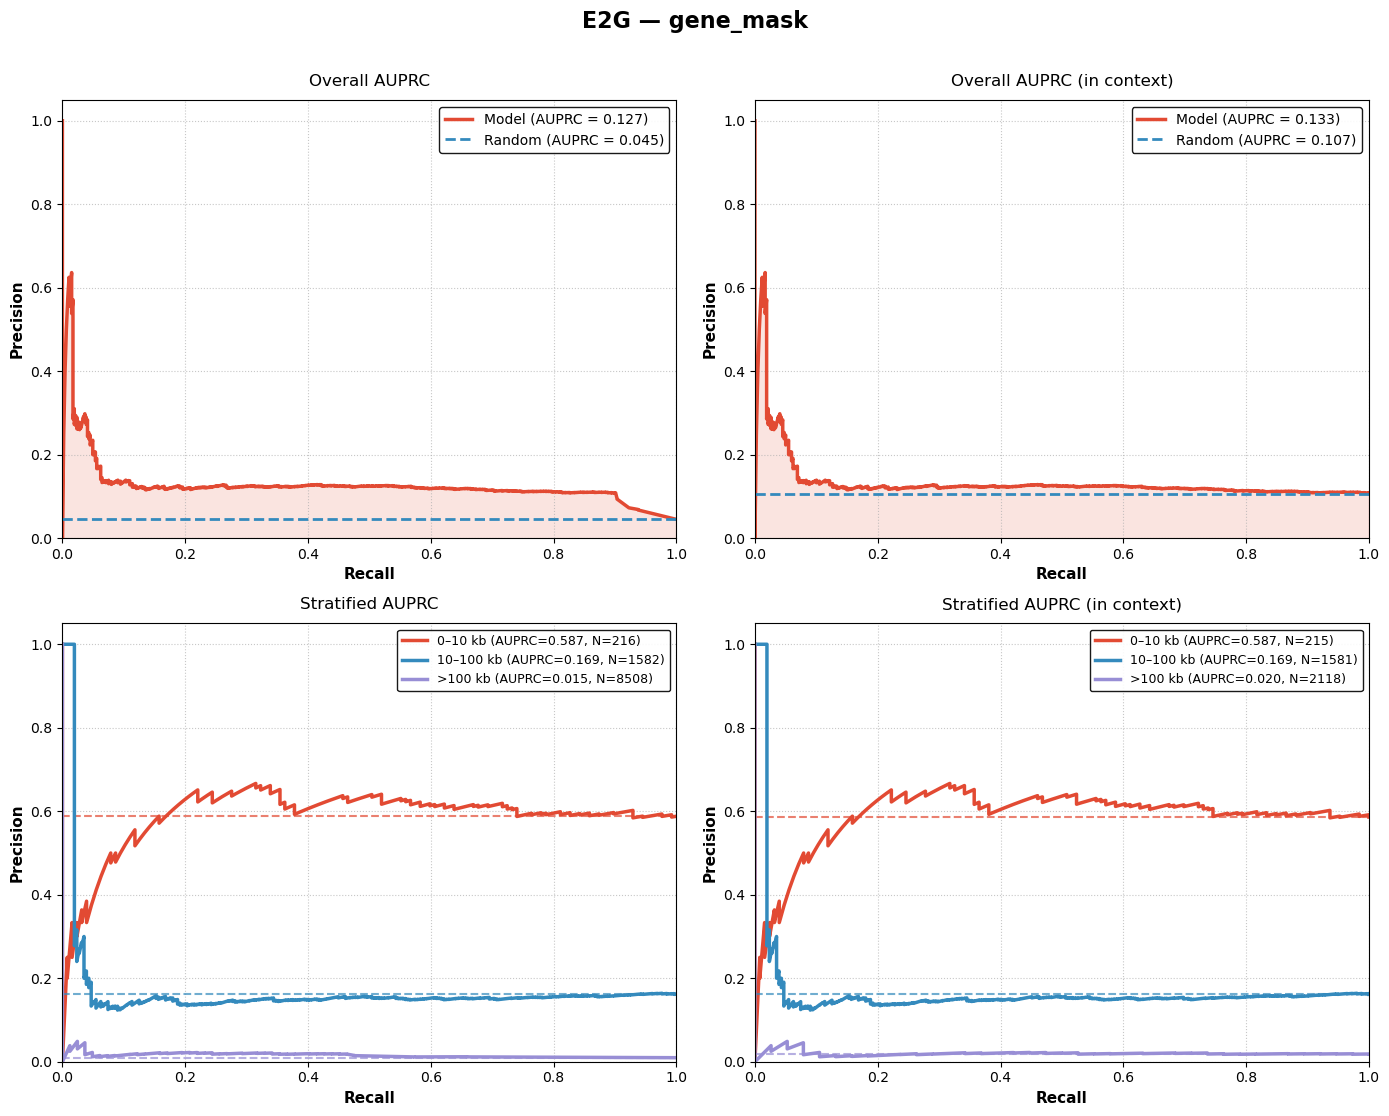

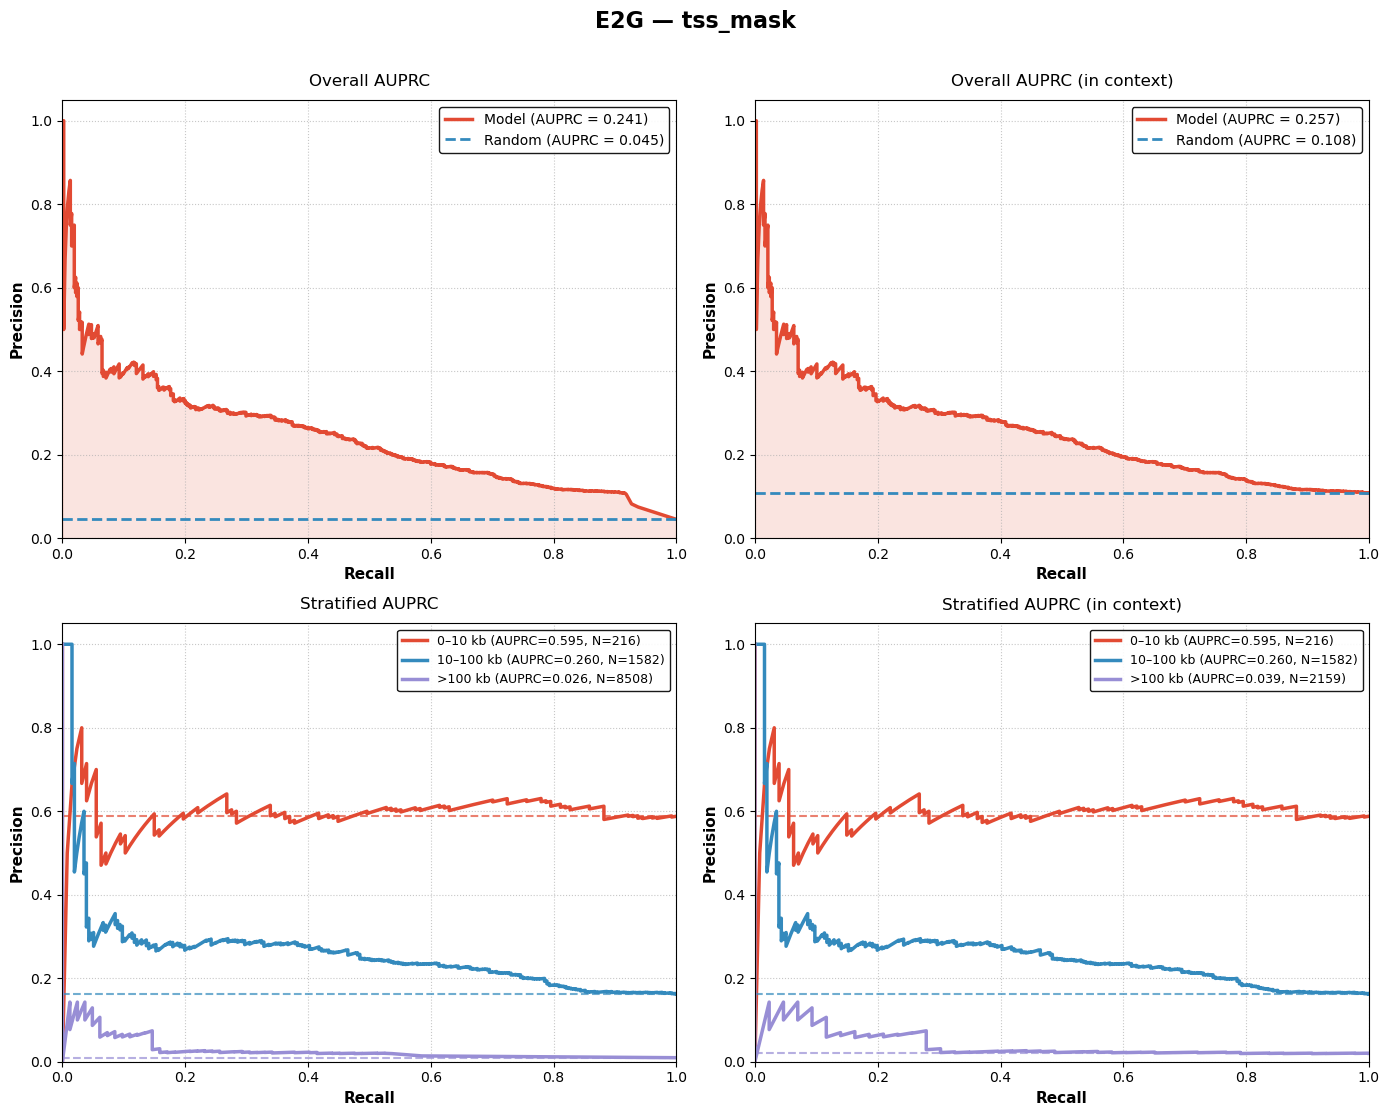

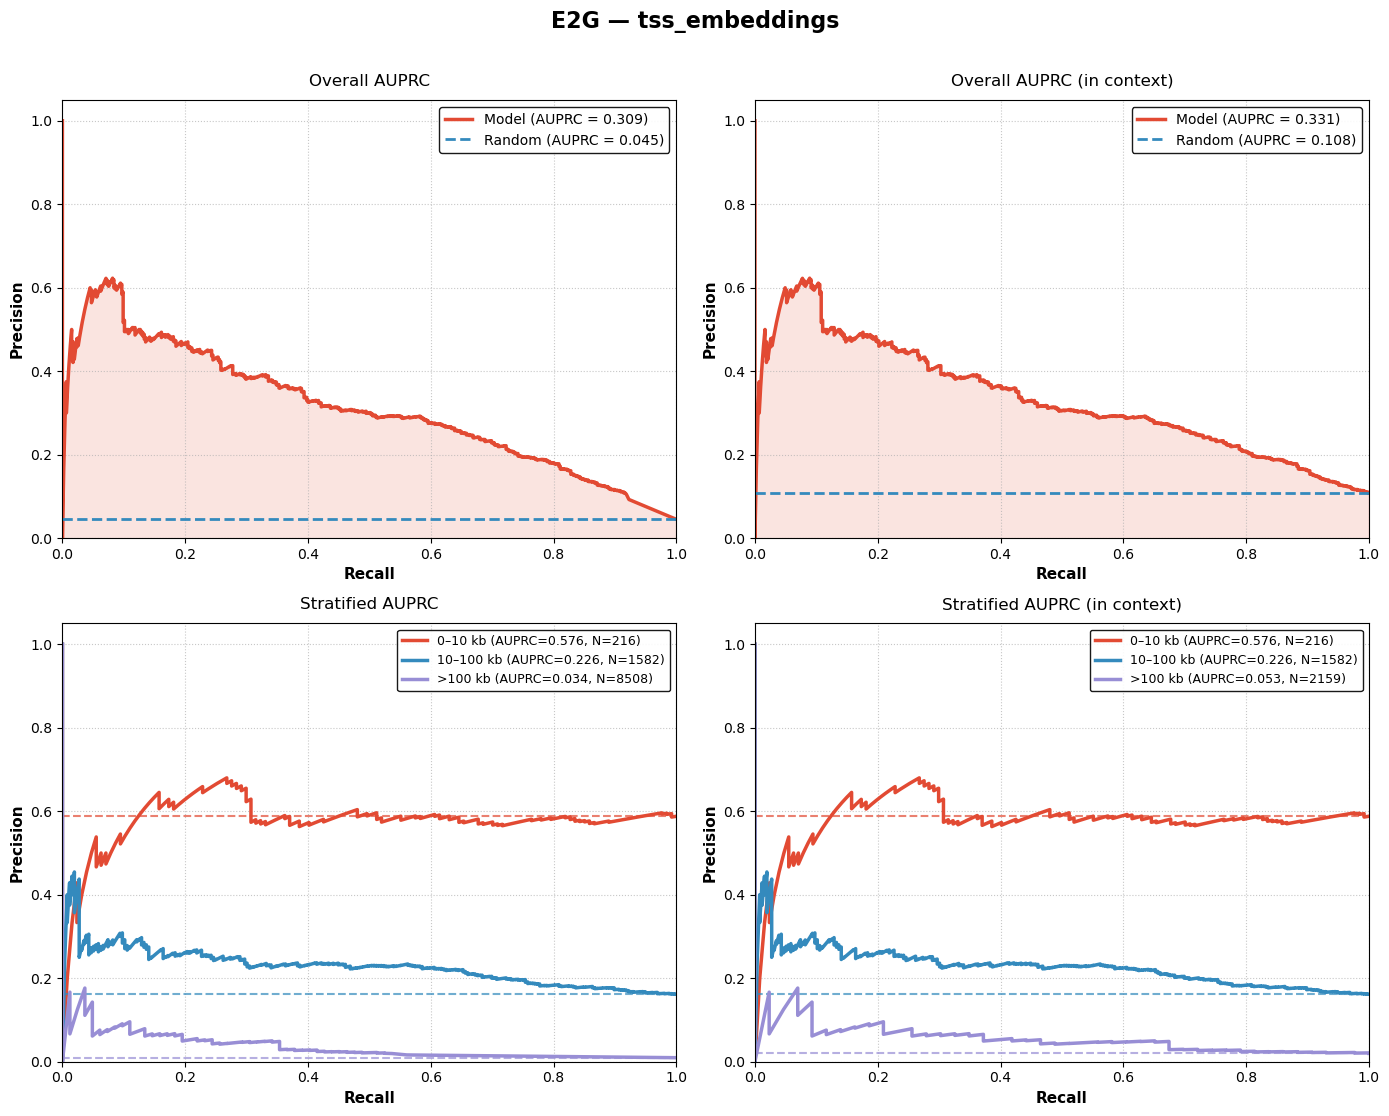

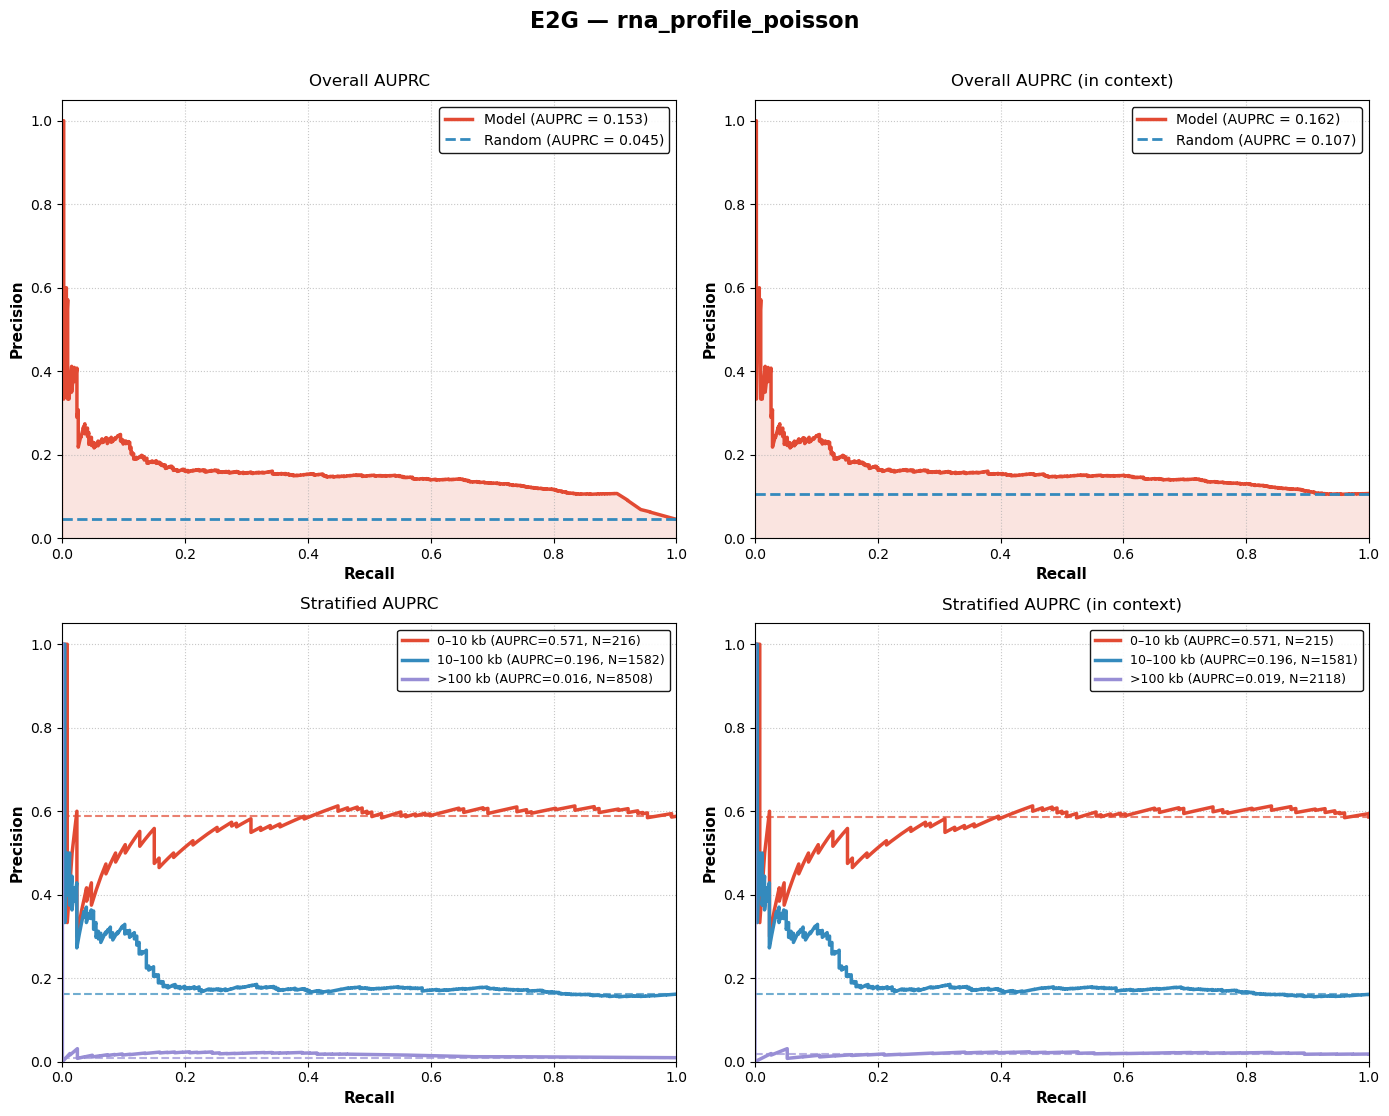

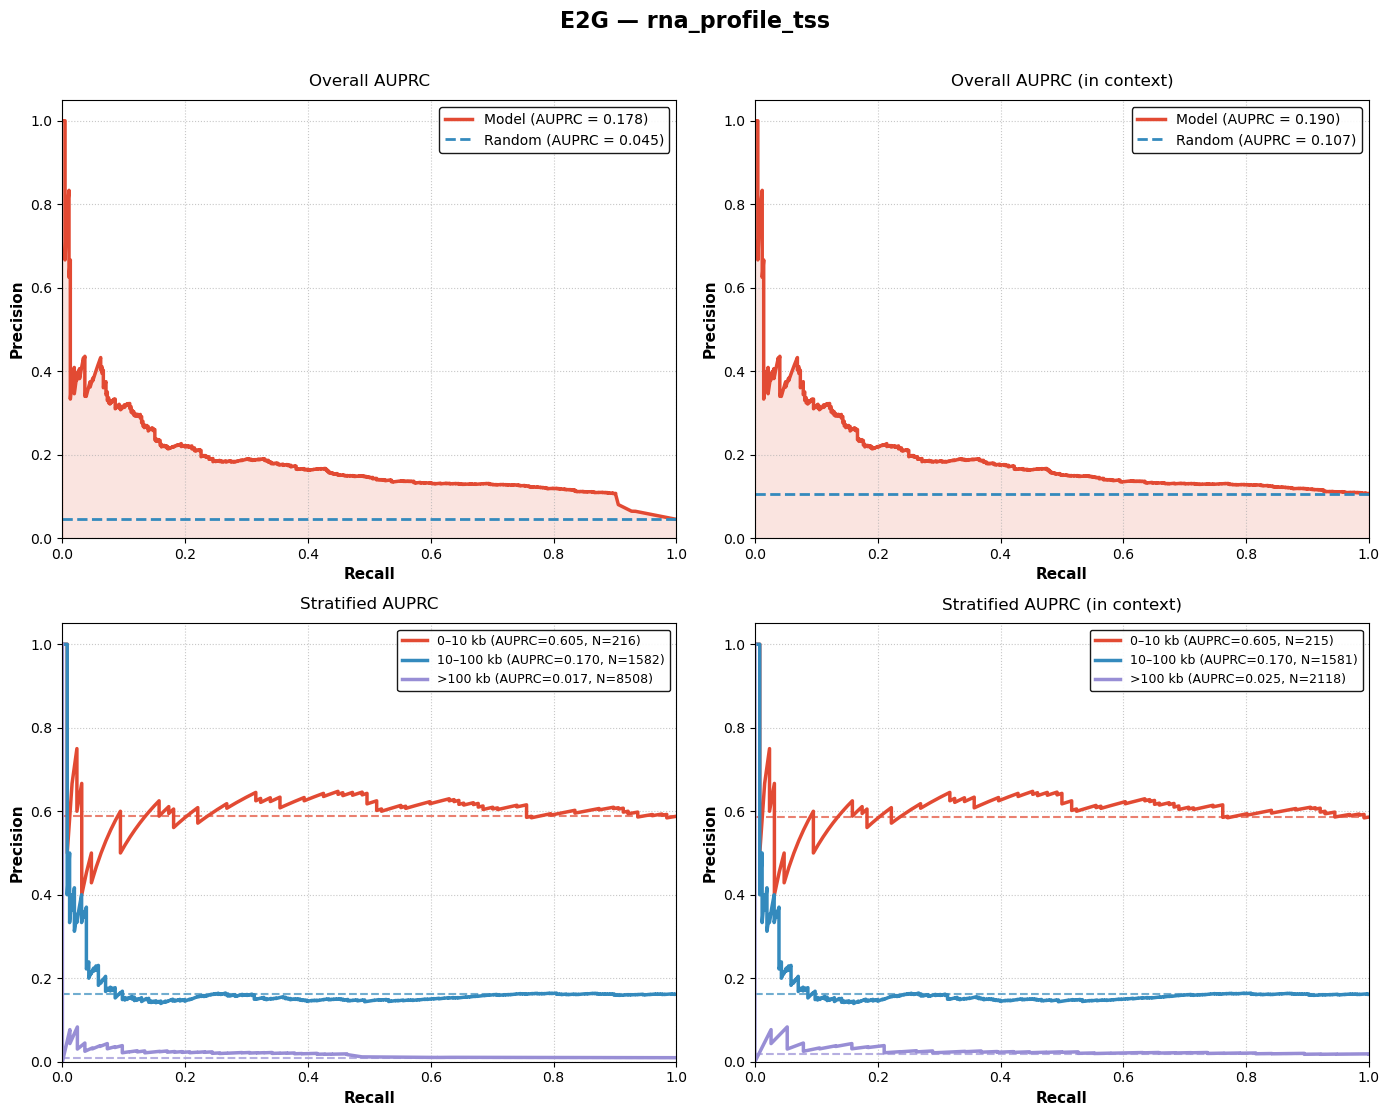

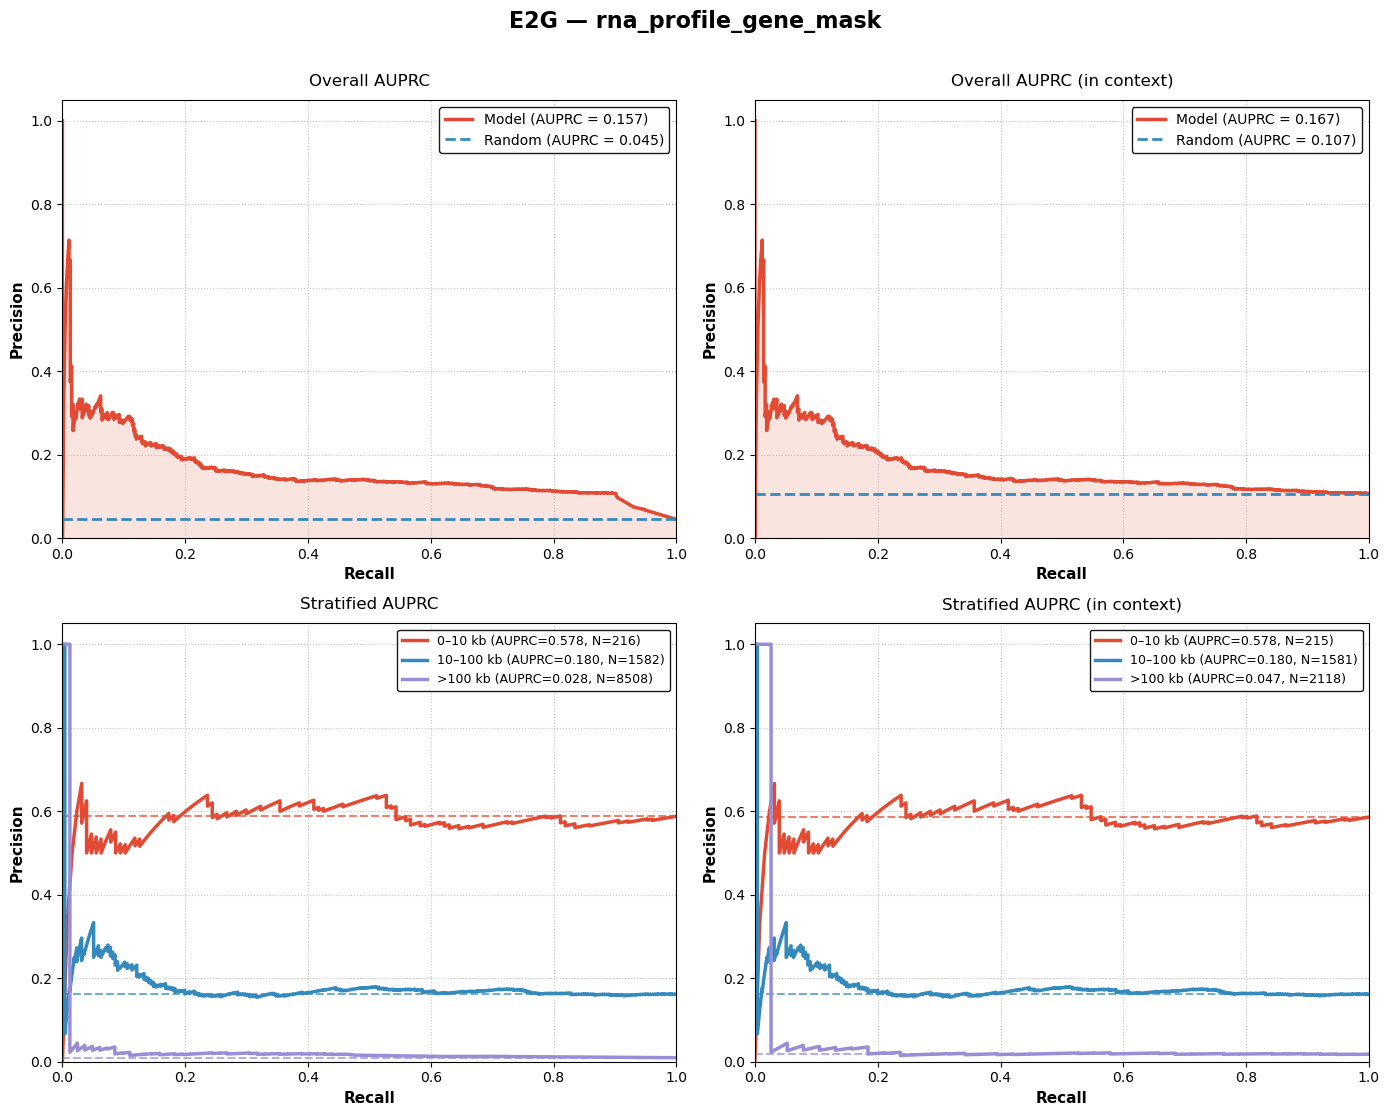

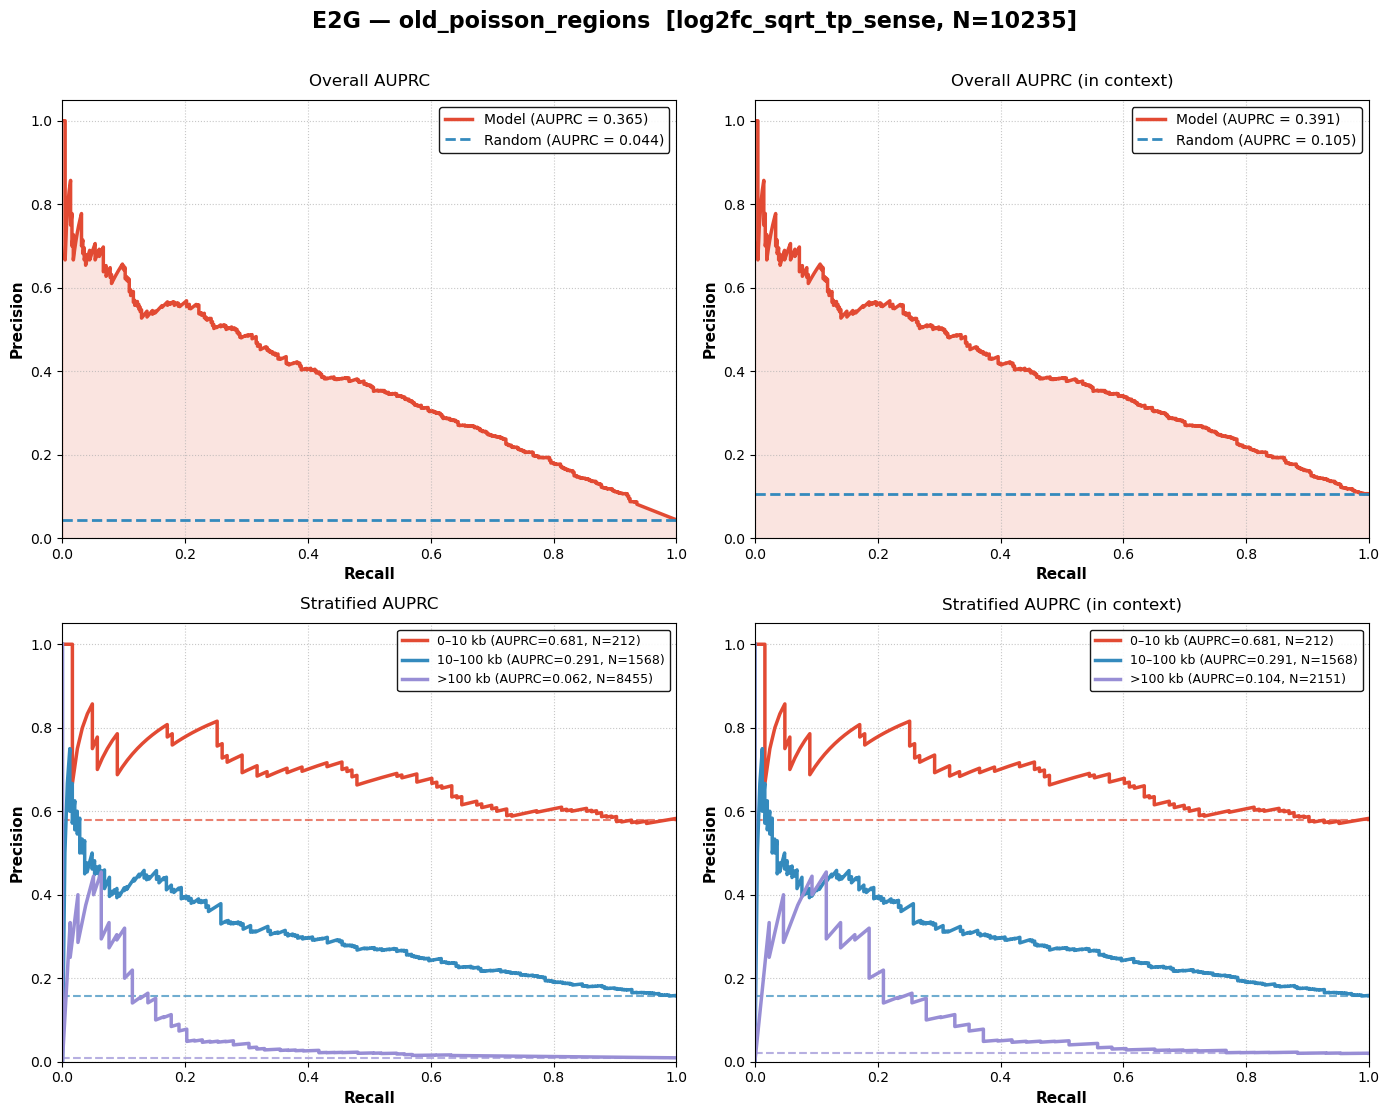

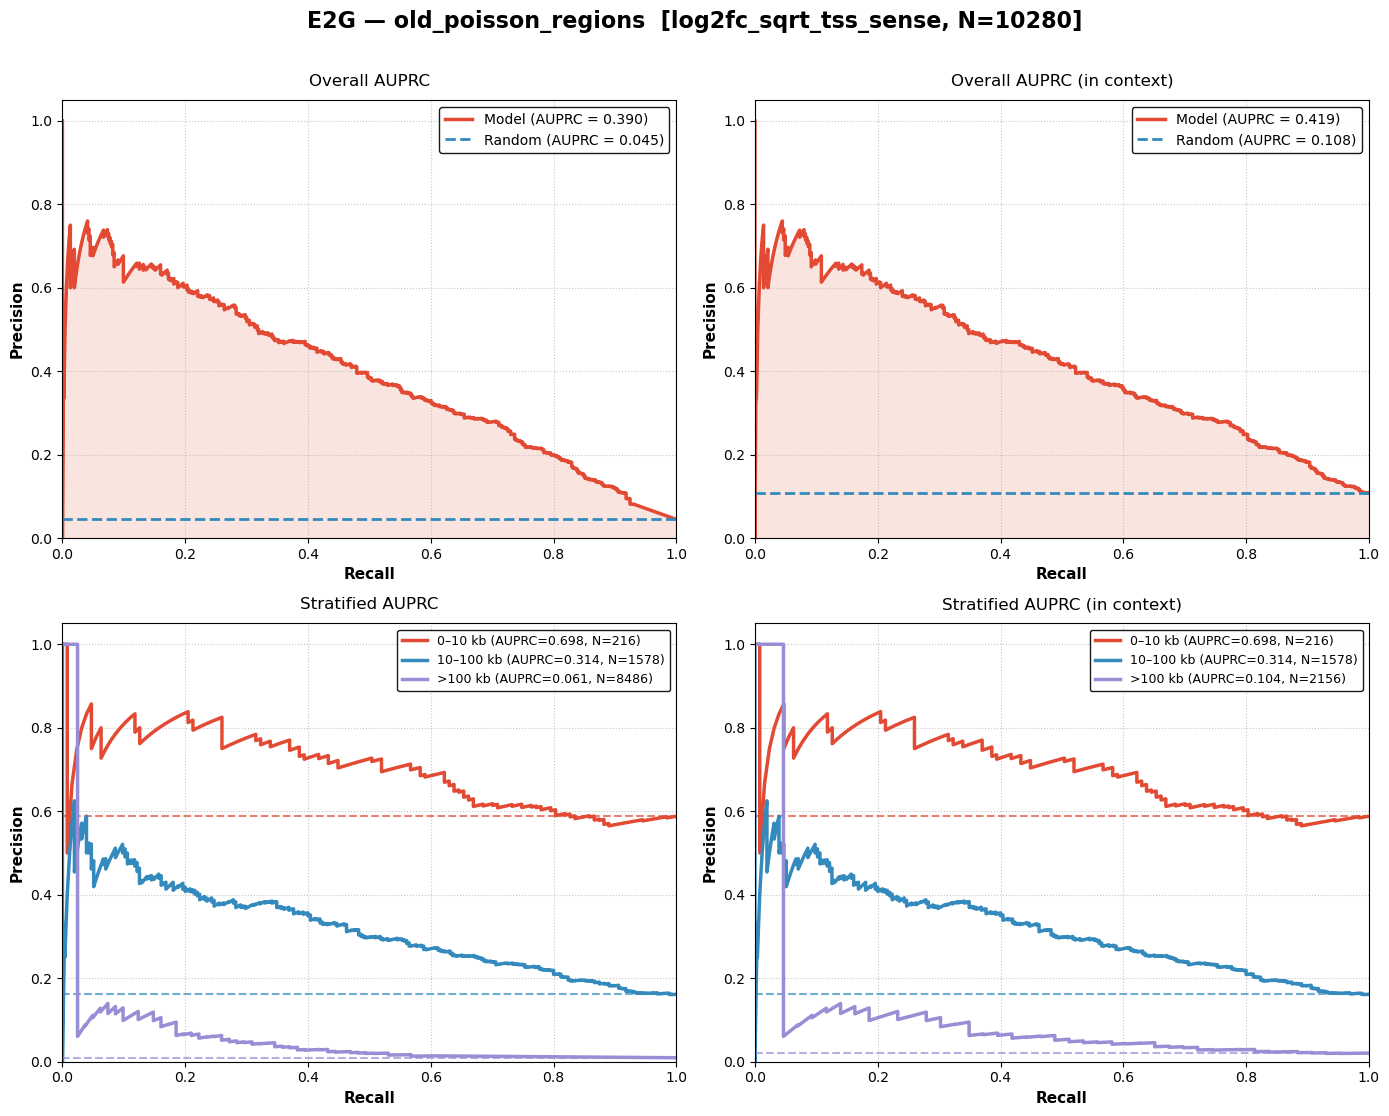

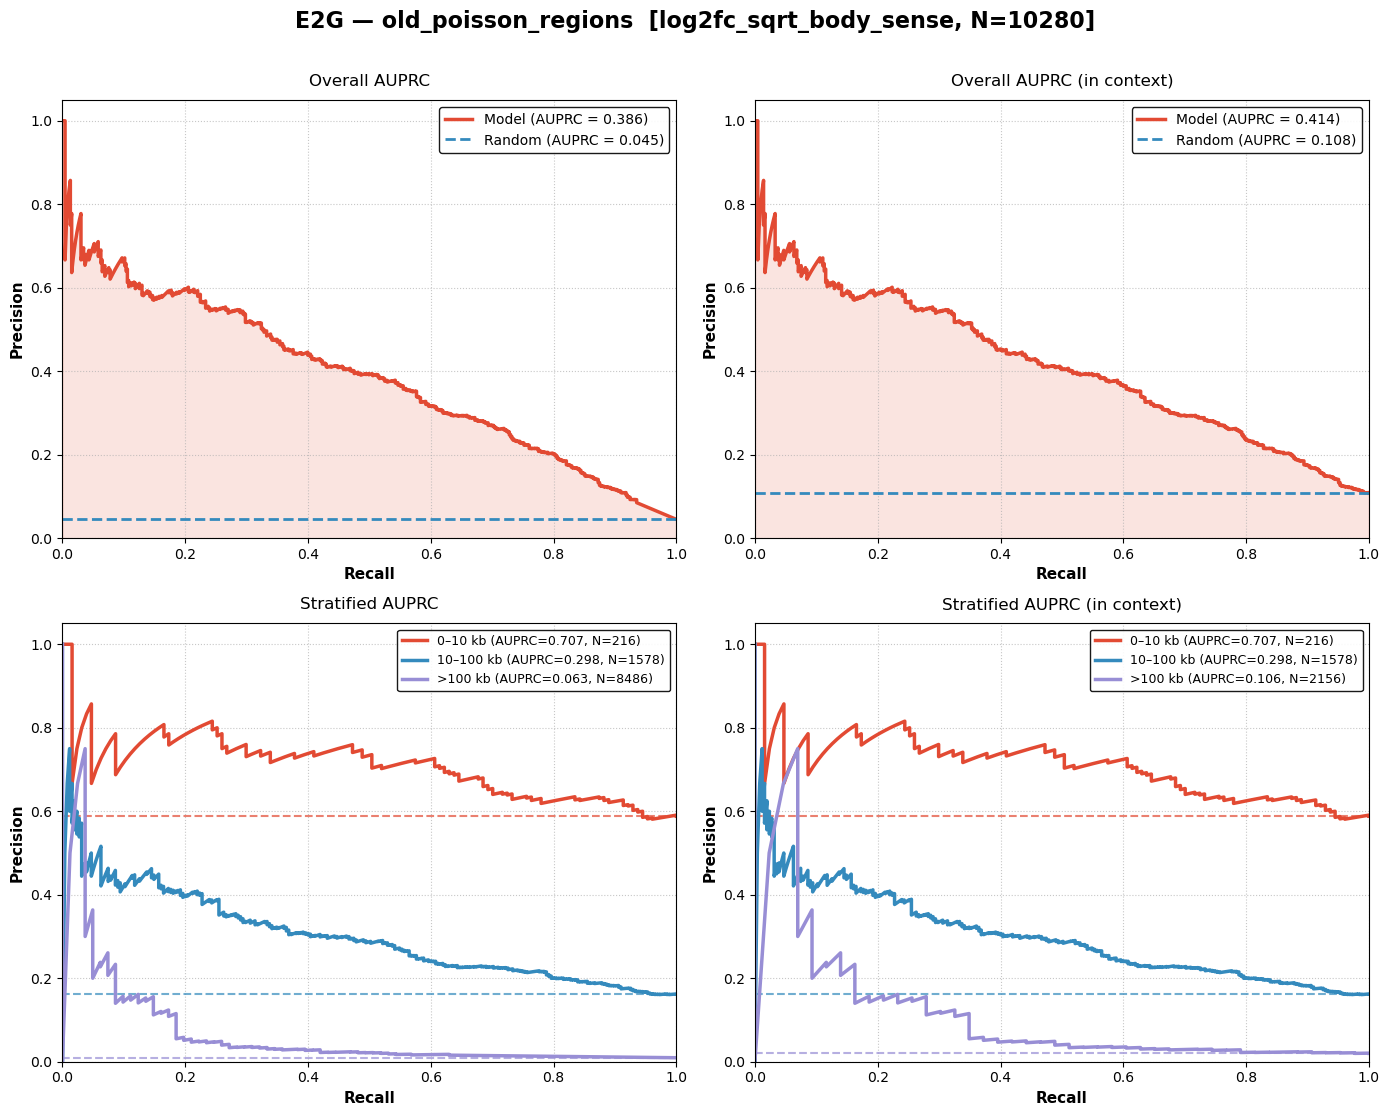

In [15]:
# Each model on its own pair set. Strictly comparable curves are in 8b.
# The 3' model gets one figure PER AGGREGATION WINDOW: the distance stratification is the
# interesting part of this figure and the three windows behave differently in it (see 8a). Each
# window uses its own non-NaN mask, so the tp panels sit on 45 fewer pairs than tss/body -- N is
# printed in the title. Sense strand only here; the antisense control is 8a's job.
THREE_PRIME_WINDOWS = [("tp", "score"), ("tss", "score2"), ("body", "score3")]

for name in NAMES7:
    if name == "old_poisson_regions":
        d = e2g[name]
        for win, key in THREE_PRIME_WINDOWS:
            ok = ~np.isnan(d[key])
            plot_auprc_2x2(d[key][ok], d["in_context"][ok], d["y_true"][ok], d["distance"][ok],
                           title=f"E2G — {name}  "
                                 f"[log2fc_{THREE_PRIME_SPACE}_{win}_sense, N={int(ok.sum())}]")
    else:
        a = model_arrays(name)
        plot_auprc_2x2(a["score"], a["in_context"], a["y_true"], a["distance"],
                       title=f"E2G — {name}")

### 8a. Which window, which strand, and which output space for `old_poisson_regions`?

`e2g_3prime.py` saved three aggregation windows and both strands precisely so this could be checked
rather than assumed, with the antisense strand as a control that *should* be much less responsive
than the sense strand if the model has learned strand-specific 3′ transcription. The check matters:
if the antisense control is as good or better, the AUPRC is not measuring a strand-specific
expression response, whatever else it is measuring.

Two output spaces are scored side by side. **`sqrt`** is the model's own space and is exact for this
checkpoint. **`recon`** is the count-space reconstruction `(pred+1)² - 1` rebuilt from the saved
sums, reported for the sense windows only and only on rows whose bracket is under `RECON_TOL` — it
exists to confirm that the ranking is not an artifact of scoring in sqrt space. The broken `raw`
columns are scored too, purely to show what the wrong inverse does to the numbers; do not quote
them.

,space,window,strand,subset,N,dropped,baseline,|score|,-score,+score,eff_r
0,sqrt,body,sense,all,10280,0,0.0450,0.3857,0.2242,0.2016,-0.1565
1,sqrt,body,sense,in context,3950,0,0.1076,0.4138,0.2662,0.2404,-0.1748
2,sqrt,body,anti,all,10280,0,0.0450,0.3117,0.1548,0.1916,0.1236
3,sqrt,body,anti,in context,3950,0,0.1076,0.3334,0.1923,0.2293,0.1336
4,sqrt,tp,sense,all,10235,45,0.0440,0.3650,0.2203,0.1846,-0.1600
5,sqrt,tp,sense,in context,3931,45,0.1053,0.3909,0.2612,0.2217,-0.1797
6,sqrt,tp,anti,all,10235,45,0.0440,0.2781,0.1545,0.1588,0.0904
7,sqrt,tp,anti,in context,3931,45,0.1053,0.2966,0.1899,0.1950,0.0981
8,sqrt,tss,sense,all,10280,0,0.0450,0.3904,0.1818,0.2496,-0.0961
9,sqrt,tss,sense,in context,3950,0,0.1076,0.4193,0.2240,0.2894,-0.1074


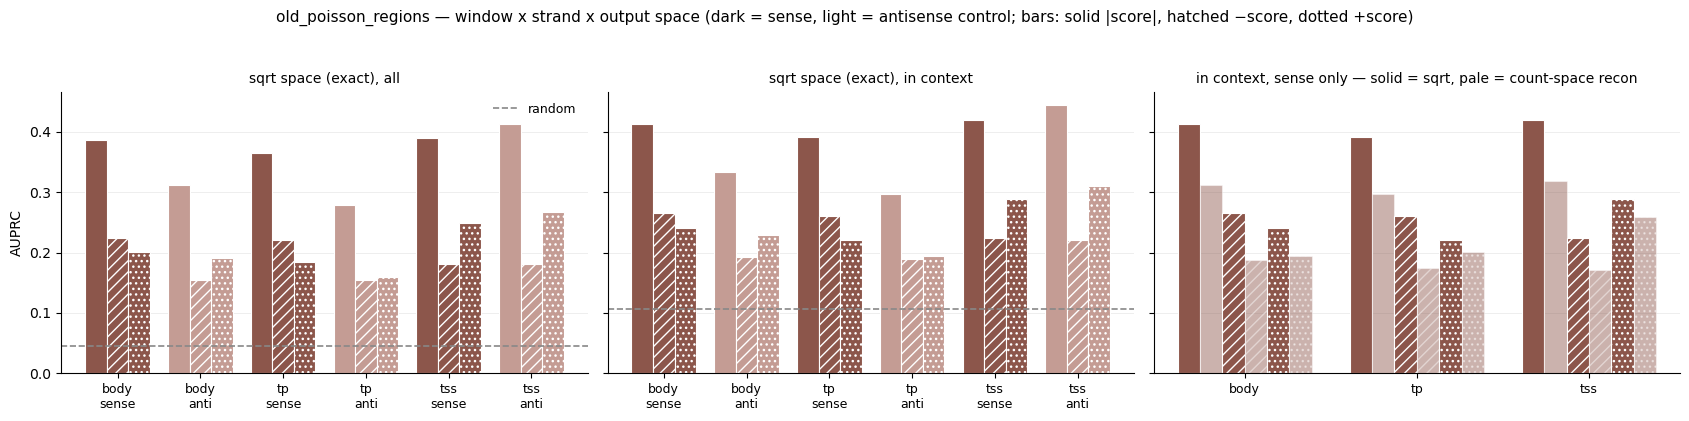

In [16]:
from scipy import stats

variants = {"|score|": np.abs, "-score": lambda s: -s, "+score": lambda s: s}
WINDOWS_3P = [(w, st) for w in ("body", "tp", "tss") for st in ("sense", "anti")]

d3 = e2g["old_poisson_regions"]
rows = []
for space in ("sqrt", "recon", "raw"):
    for win, st in WINDOWS_3P:
        if space == "recon":
            if st == "anti":
                continue          # bracket is ~12 log2 units wide antisense -- meaningless
            s = recon_df[f"log2fc_recon_{win}_{st}"].values
            ok = ~np.isnan(s) & (recon_df[f"bracket_{win}_{st}"].values < RECON_TOL)
        else:
            s = tp_df[f"log2fc_{space}_{win}_{st}"].values
            ok = ~np.isnan(s)
        for subset, mask in [("all", ok), ("in context", ok & d3["in_context"])]:
            yt = d3["y_true"][mask]
            entry = {"space": space, "window": win, "strand": st, "subset": subset,
                     "N": int(mask.sum()), "dropped": int((~ok).sum()), "baseline": yt.mean()}
            for vname, fn in variants.items():
                prec, rec, _ = precision_recall_curve(yt, fn(s[mask]))
                entry[vname] = auc(rec, prec)
            # sign convention: -log2fc is "predicted to be repressed", and every Regulated pair has
            # a negative EffectSize, so a model with the right direction gives a negative r here
            entry["eff_r"] = stats.pearsonr(-s[mask], d3["effect"][mask])[0]
            rows.append(entry)
win_df = pd.DataFrame(rows)
display(win_df.round(4))

# left/middle: the exact sqrt space, all pairs and in context. right: the count-space
# reconstruction on the sense windows, as a check that the ranking is not a sqrt-space artifact.
fig, axes = plt.subplots(1, 3, figsize=(17, 4.0), sharey=True)
strand_color = {"sense": "#8c564b", "anti": "#c49c94"}

for ax, subset in zip(axes[:2], ["all", "in context"]):
    sub = win_df[(win_df["space"] == "sqrt") & (win_df["subset"] == subset)] \
        .set_index(["window", "strand"])
    x = np.arange(len(WINDOWS_3P))
    w = 0.26
    for i, (vname, hatch) in enumerate(zip(variants, [None, "///", "..."])):
        ax.bar(x + (i - 1) * w, [sub.loc[k, vname] for k in WINDOWS_3P], w,
               color=[strand_color[st] for _, st in WINDOWS_3P], hatch=hatch,
               edgecolor="white", linewidth=0.8)
    ax.axhline(sub["baseline"].mean(), color="#888", linestyle="--", lw=1.2, label="random")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{w_}\n{st}" for w_, st in WINDOWS_3P], fontsize=9)
    ax.set_title(f"sqrt space (exact), {subset}", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)

ax = axes[2]
sense_wins = [(w_, st) for w_, st in WINDOWS_3P if st == "sense"]
x = np.arange(len(sense_wins))
w = 0.26
for i, (vname, hatch) in enumerate(zip(variants, [None, "///", "..."])):
    for space, alpha in [("sqrt", 1.0), ("recon", 0.45)]:
        sub = win_df[(win_df["space"] == space) & (win_df["subset"] == "in context")] \
            .set_index(["window", "strand"])
        off = 0 if space == "sqrt" else w / 2
        ax.bar(x + (i - 1) * w - w / 4 + off, [sub.loc[k, vname] for k in sense_wins], w / 2,
               color="#8c564b", alpha=alpha, hatch=hatch, edgecolor="white", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([w_ for w_, _ in sense_wins], fontsize=9)
ax.set_title("in context, sense only — solid = sqrt, pale = count-space recon", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)

axes[0].set_ylabel("AUPRC")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("old_poisson_regions — window x strand x output space "
             "(dark = sense, light = antisense control; bars: solid |score|, hatched −score, "
             "dotted +score)", fontsize=11, y=1.04)
plt.tight_layout()
plt.show()

### 8b. Head-to-head

The six TSS models share one pair set (10306); `old_poisson_regions` has 10280, a strict subset.
The panels below restrict to the intersection, minus the rows where the 3′ window score is NaN, so
all seven curves sit on one identical subset. The right panel further restricts to pairs in context
for *all seven* models — the only subset where every model actually saw the perturbation, and note
that this is bounded by the asymmetric-window models' 3914.

The three brown curves are the same 3′ model scored on its three aggregation windows, all in sqrt
space, carried over from 8a: **solid = `tp`** (the 3′-terminal 10 kb, the a-priori headline),
**dashed = `tss`** (TSS ± 2 kb), **dotted = `body`** (the full collapsed gene body). Read the legend
carefully before attributing the top curve to a TSS model.

Two things to keep in mind when comparing `body` against `tp`: over half the genes here are shorter
than 10 kb, so for most pairs the two windows are the *same interval* and the curves can only
separate on the longer genes; and all three brown curves are drawn on the shared subset, which drops
the 45 rows where the `tp` score is NaN even though `body` is defined there — that keeps every curve
in the figure on an identical pair set.

10235 pairs shared by all seven models (10306 ∩ 10280, minus 45 NaN 3′-window rows)
in context per model: gene_mask=3890, tss_mask=3931, tss_embeddings=3931, rna_profile_poisson=3890, rna_profile_tss=3890, rna_profile_gene_mask=3890, old_poisson_regions=3931
in context for all seven: 3355


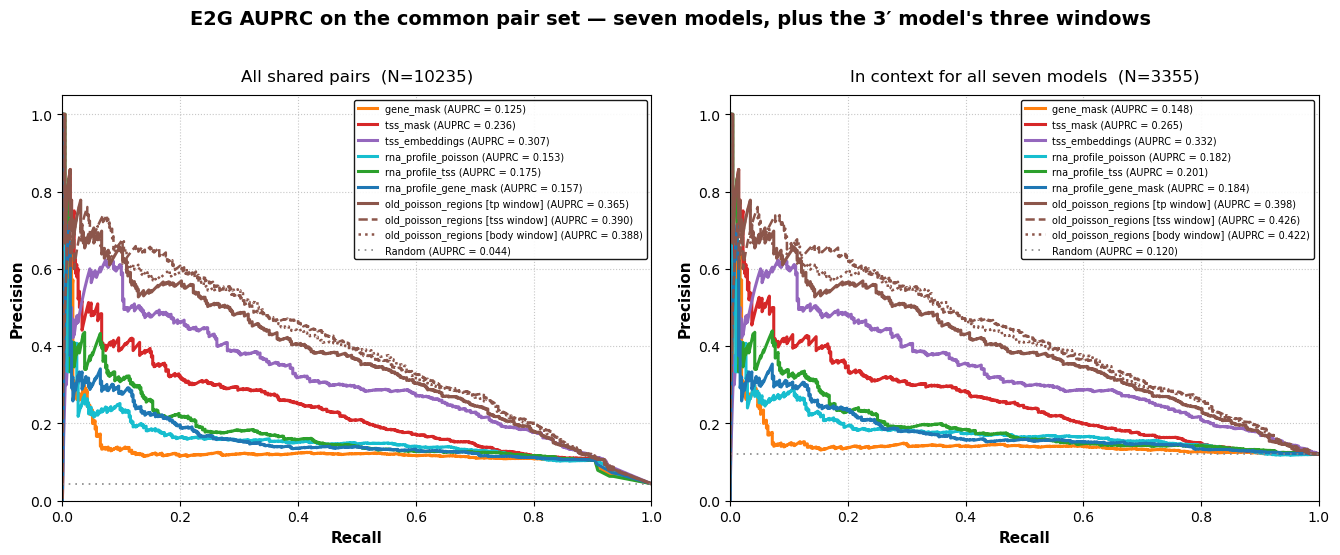

In [17]:
shared_masters = set.intersection(*[set(e2g[n]["master"][e2g[n]["valid"]]) for n in NAMES7])
shared_order = [m for m in e2g[NAMES[0]]["master"] if m in shared_masters]
print(f"{len(shared_order)} pairs shared by all seven models "
      f"(10306 ∩ 10280, minus {int((~e2g['old_poisson_regions']['valid']).sum())} "
      f"NaN 3′-window rows)")

aligned = {}
for name in NAMES7:
    d = e2g[name]
    pos = {m: i for i, m in enumerate(d["master"])}
    idx = np.array([pos[m] for m in shared_order])
    aligned[name] = {k: d[k][idx] for k in
                     ("score", "in_context", "y_true", "distance", "effect")}
    for extra in ("score2", "score3"):
        if d[extra] is not None:
            aligned[name][extra] = d[extra][idx]

y_shared = aligned[NAMES7[0]]["y_true"]
for name in NAMES7[1:]:
    assert (aligned[name]["y_true"] == y_shared).all(), "labels must agree on shared pairs"

ctx_all = np.logical_and.reduce([aligned[n]["in_context"] for n in NAMES7])
print("in context per model: "
      + ", ".join(f"{n}={int(aligned[n]['in_context'].sum())}" for n in NAMES7))
print(f"in context for all seven: {int(ctx_all.sum())}")

# the 3prime model contributes three curves, so name the window in the legend rather than letting
# three brown entries differ only by linestyle
LABEL7 = {n: n for n in NAMES7}
LABEL7["old_poisson_regions"] = "old_poisson_regions [tp window]"
# (score key, linestyle, window name) for the 3prime model's non-headline windows
THREE_PRIME_EXTRA = [("score2", "--", "tss"), ("score3", ":", "body")]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))
for ax, mask, subtitle in [(axes[0], np.ones(len(y_shared), bool), "All shared pairs"),
                           (axes[1], ctx_all, "In context for all seven models")]:
    yt = y_shared[mask]
    for name in NAMES7:
        prec, rec, _ = precision_recall_curve(yt, np.abs(aligned[name]["score"][mask]))
        ax.plot(rec, prec, color=COLORS[name], lw=2.2,
                label=f"{LABEL7[name]} (AUPRC = {auc(rec, prec):.3f})")
    # the 3prime model's other two windows, from 8a
    for key, ls, win in THREE_PRIME_EXTRA:
        prec, rec, _ = precision_recall_curve(
            yt, np.abs(aligned["old_poisson_regions"][key][mask]))
        ax.plot(rec, prec, color=COLORS["old_poisson_regions"], lw=1.8, linestyle=ls,
                label=f"old_poisson_regions [{win} window] (AUPRC = {auc(rec, prec):.3f})")
    ax.axhline(yt.mean(), color="#888", lw=1.2, linestyle=(0, (1, 3)),
               label=f"Random (AUPRC = {yt.mean():.3f})")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Recall", fontsize=11, fontweight="bold")
    ax.set_ylabel("Precision", fontsize=11, fontweight="bold")
    ax.set_title(f"{subtitle}  (N={int(mask.sum())})", fontsize=12, pad=10)
    ax.grid(True, linestyle=":", alpha=0.7)
    ax.legend(loc="upper right", fontsize=7, framealpha=0.9, edgecolor="black")

fig.suptitle("E2G AUPRC on the common pair set — seven models, plus the 3′ model's three windows",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### 8c. Score direction

Lowering an enhancer's accessibility should *lower* predicted expression, so `-score` ought to be
the discriminative direction. `|score|` winning means the model responds to the perturbation
without a consistent sign, and `+score` winning means it is outright inverted. Two things are worth
reading separately: the **offset** (mean in-context score, % negative) and the **ranking** (which
variant maximizes AUPRC) — a model can be badly offset and still rank correctly, or vice versa.

run                       mean score  % negative       std   units  (in-context pairs)
gene_mask                    +0.0184      19.3%    0.0574   natural log
tss_mask                     +0.0060      30.9%    0.0321   natural log
tss_embeddings               +0.0012      45.4%    0.0517   natural log
rna_profile_poisson          +0.0030      34.5%    0.0721   natural log
rna_profile_tss              +0.0021      27.5%    0.0510   natural log
rna_profile_gene_mask        -0.0010      30.4%    0.0787   natural log
old_poisson_regions          -0.0019      35.5%    0.0843   log2 FC (sqrt space)


,model,subset,N,baseline,|score|,-score,+score
0,gene_mask,all,10306,0.0451,0.1266,0.1424,0.0819
1,gene_mask,in context,3914,0.1071,0.1334,0.2069,0.1050
2,tss_mask,all,10306,0.0451,0.2414,0.0621,0.2128
3,tss_mask,in context,3957,0.1077,0.2574,0.1051,0.2399
4,tss_embeddings,all,10306,0.0451,0.3089,0.1740,0.1751
5,tss_embeddings,in context,3957,0.1077,0.3306,0.2138,0.2112
6,rna_profile_poisson,all,10306,0.0451,0.1530,0.1298,0.0743
7,rna_profile_poisson,in context,3914,0.1071,0.1621,0.1784,0.1015
8,rna_profile_tss,all,10306,0.0451,0.1775,0.1299,0.0949
9,rna_profile_tss,in context,3914,0.1071,0.1903,0.1821,0.1213


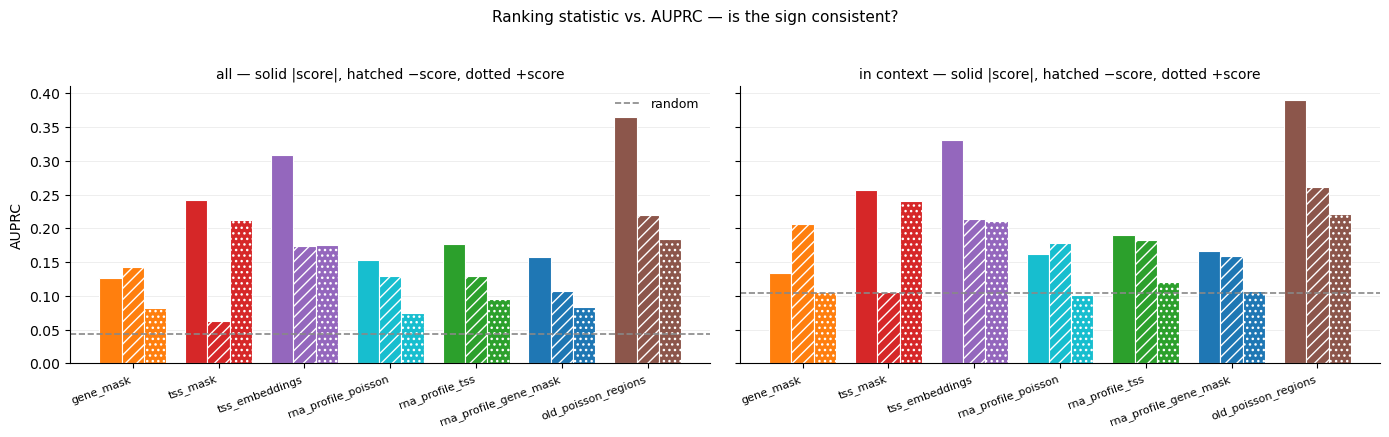

In [18]:
print(f"{'run':24s}{'mean score':>12s}{'% negative':>12s}{'std':>10s}   units  (in-context pairs)")
for name in NAMES7:
    d = e2g[name]
    s = d["score"][d["in_context"] & d["valid"]]
    print(f"{name:24s}{s.mean():+12.4f}{np.mean(s < 0):11.1%}{s.std():10.4f}   {d['units']}")

rows = []
for name in NAMES7:
    a = model_arrays(name)
    for subset, mask in [("all", np.ones(len(a["y_true"]), bool)), ("in context", a["in_context"])]:
        yt = a["y_true"][mask]
        entry = {"model": name, "subset": subset, "N": int(mask.sum()), "baseline": yt.mean()}
        for vname, fn in variants.items():
            prec, rec, _ = precision_recall_curve(yt, fn(a["score"][mask]))
            entry[vname] = auc(rec, prec)
        rows.append(entry)
# the 3' model's count-space reconstruction, on the rows where the bracket is tight enough
d3 = e2g["old_poisson_regions"]
rec_ok = d3["valid"] & (d3["recon_bracket"] < RECON_TOL)
for subset, mask in [("all", rec_ok), ("in context", rec_ok & d3["in_context"])]:
    yt = d3["y_true"][mask]
    entry = {"model": "old_poisson_regions [count recon]", "subset": subset,
             "N": int(mask.sum()), "baseline": yt.mean()}
    for vname, fn in variants.items():
        prec, rec, _ = precision_recall_curve(yt, fn(d3["score_recon"][mask]))
        entry[vname] = auc(rec, prec)
    rows.append(entry)

sign_df = pd.DataFrame(rows)
display(sign_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharey=True)
x = np.arange(len(NAMES7))
w = 0.26
for ax, subset in zip(axes, ["all", "in context"]):
    sub = sign_df[sign_df["subset"] == subset].set_index("model")
    for i, (vname, hatch) in enumerate(zip(variants, [None, "///", "..."])):
        ax.bar(x + (i - 1) * w, [sub.loc[n, vname] for n in NAMES7], w,
               color=[COLORS[n] for n in NAMES7], hatch=hatch, edgecolor="white",
               linewidth=0.8)
    ax.axhline(sub["baseline"].mean(), color="#888", linestyle="--", lw=1.2, label="random")
    ax.set_xticks(x)
    ax.set_xticklabels(NAMES7, rotation=20, ha="right", fontsize=8)
    ax.set_title(f"{subset} — solid |score|, hatched −score, dotted +score", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)

axes[0].set_ylabel("AUPRC")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("Ranking statistic vs. AUPRC — is the sign consistent?", fontsize=11, y=1.03)
plt.tight_layout()
plt.show()


### 8d. Model score vs. CRISPRi effect size

The plotted score is `-score`, so positive means "predicted to be repressed by the knockdown".
Every `Regulated` pair in the benchmark has a *negative* `EffectSize`, so a model that gets the
direction right produces a **negative** `r` here; a positive `r` means it moves the wrong way.

x-axis units differ for `old_poisson_regions` (log2 fold-change of summed profile counts, not a
log-expression difference), so the panels are not overlayable — but `r` is scale-free and
comparable.

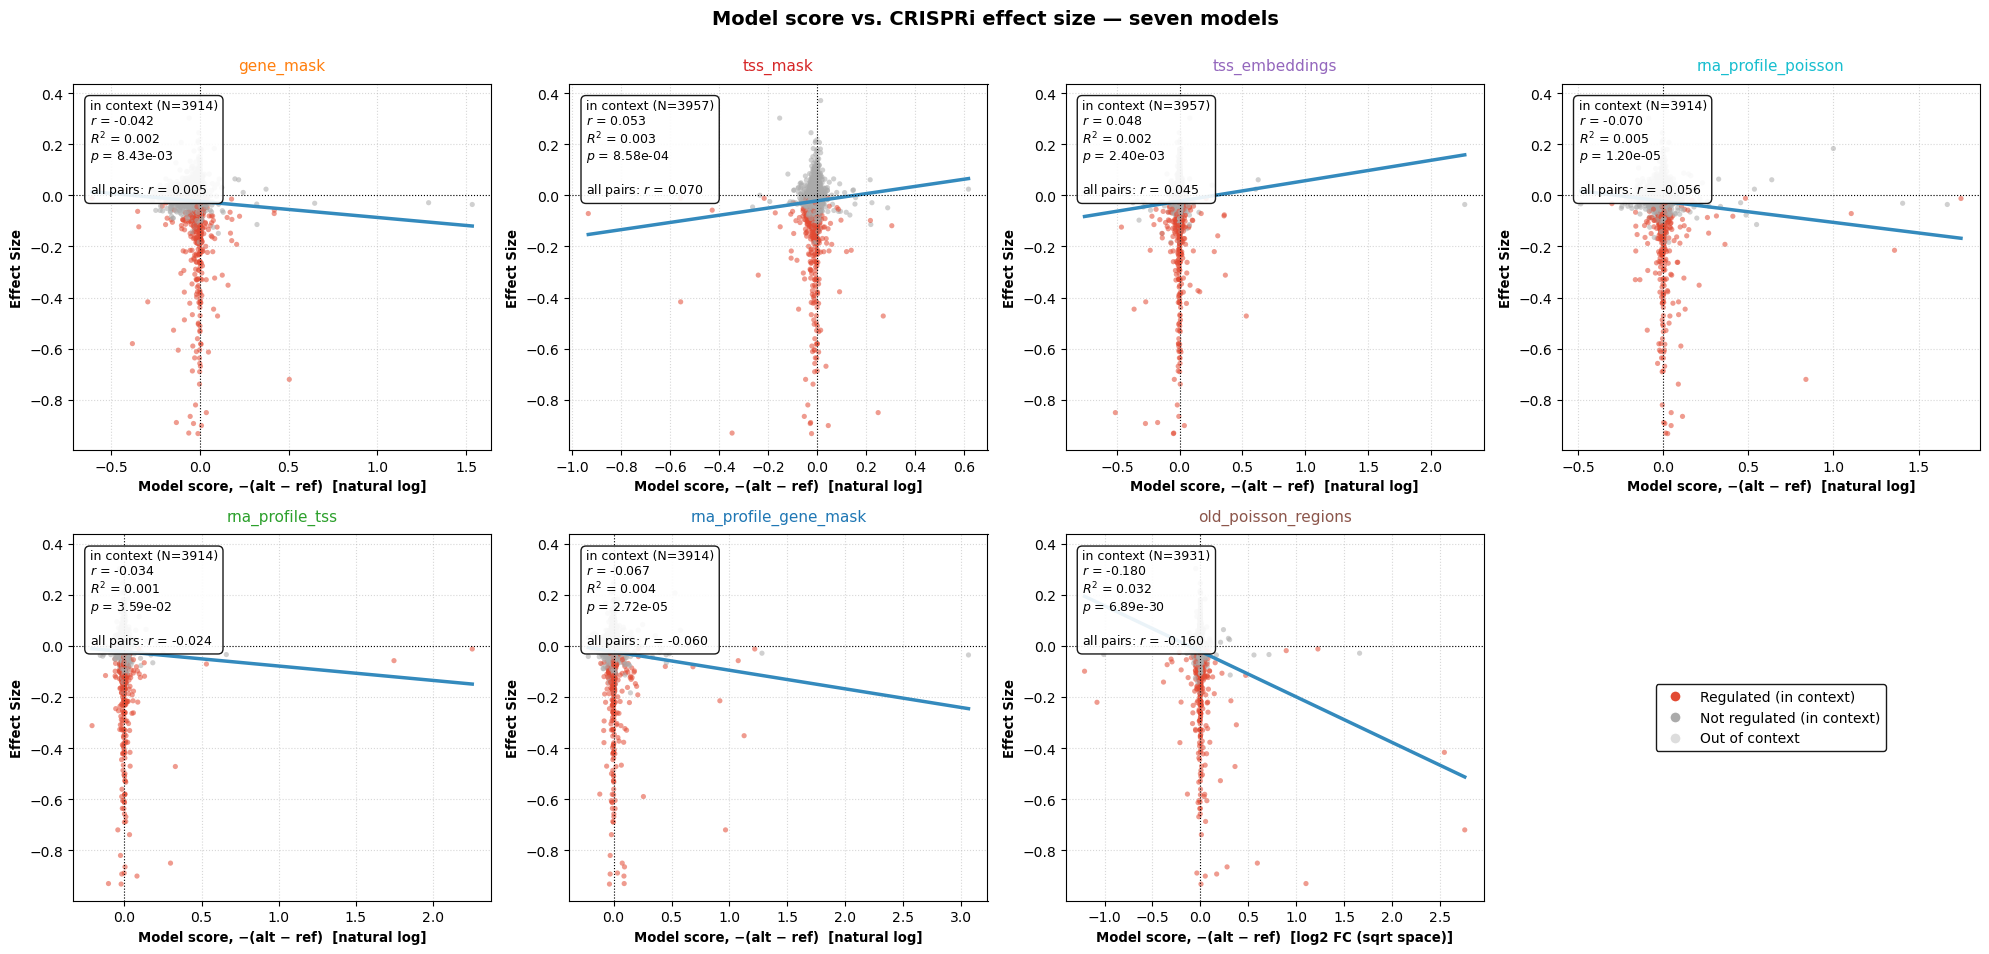

In [19]:
from scipy import stats
from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 4, figsize=(20, 9.5))
flat = axes.ravel()

for ax, name in zip(flat, NAMES7):
    a = model_arrays(name)
    model_score = -a["score"]      # no rescaling: the six TSS models are all in natural log
    effect = a["effect"]
    ctx = a["in_context"]

    ax.scatter(model_score[~ctx], effect[~ctx], c="#dddddd", alpha=0.4, s=10,
               linewidths=0, rasterized=True)
    colors = np.where(a["y_true"].astype(bool), "#E24A33", "#aaaaaa")
    ax.scatter(model_score[ctx], effect[ctx], c=colors[ctx], alpha=0.55, s=14,
               linewidths=0, rasterized=True)

    # fit on in-context pairs only; out-of-context scores are structurally ~0
    slope, intercept, r_ctx, p_ctx, _ = stats.linregress(model_score[ctx], effect[ctx])
    xs = np.linspace(model_score[ctx].min(), model_score[ctx].max(), 200)
    ax.plot(xs, intercept + slope * xs, color="#348ABD", lw=2.5)

    r_all = stats.pearsonr(model_score, effect)[0]
    p_str = f"{p_ctx:.2e}" if p_ctx > 1e-300 else "< 1e-300"
    textstr = (f"in context (N={int(ctx.sum())})\n$r$ = {r_ctx:.3f}\n$R^2$ = {r_ctx**2:.3f}\n"
               f"$p$ = {p_str}\n\nall pairs: $r$ = {r_all:.3f}")
    ax.text(0.04, 0.96, textstr, transform=ax.transAxes, fontsize=9, verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", alpha=0.9))

    ax.axhline(0, color="black", lw=0.8, linestyle=":")
    ax.axvline(0, color="black", lw=0.8, linestyle=":")
    ax.set_xlabel(f"Model score, −(alt − ref)  [{e2g[name]['units']}]", fontsize=9.5,
                  fontweight="bold")
    ax.set_ylabel("Effect Size", fontsize=9.5, fontweight="bold")
    ax.set_title(name, fontsize=11, pad=10, color=COLORS[name])
    ax.grid(True, linestyle=":", alpha=0.5)

flat[-1].axis("off")
flat[-1].legend(handles=[
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#E24A33", markersize=8,
           label="Regulated (in context)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#aaaaaa", markersize=8,
           label="Not regulated (in context)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#dddddd", markersize=8,
           label="Out of context"),
], loc="center", fontsize=10, framealpha=0.9, edgecolor="black")

fig.suptitle("Model score vs. CRISPRi effect size — seven models", fontsize=14,
             fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()

### What to read out of section 8

Baseline AUPRC is ~0.045 over all pairs and ~0.108 over in-context pairs (465 of the 10306 pairs
are labelled `Regulated`). Points to check once the cells have run, rather than pre-written
conclusions:

- **Does the profile head help E2G as much as it costs expression?** `gene_mask` vs.
  `rna_profile_gene_mask` is the clean pair — identical inputs, window and pooling, differing only
  in decoder and loss. Compare in-context `|score|` AUPRC and the effect-size `r` alongside their
  §1 metrics.
- **Poisson vs. multinomial profile term:** `rna_profile_poisson` vs. `rna_profile_gene_mask`, same
  inputs and window, different profile loss.
- **Which mask channel:** `rna_profile_tss` vs. `rna_profile_gene_mask`. Note that `tss_mask` is
  *not* a clean partner for `rna_profile_tss` — it uses the symmetric window.
- **Score the 3′ model in sqrt space, and treat the count-space number as a cross-check.** If the
  window ordering and the sense/antisense verdict agree between the exact sqrt score and the
  bracketed reconstruction, the conclusion does not depend on the transform. If they disagree, the
  rerun with the corrected `reduce_profile` is the only way to settle it.
- **The antisense control in 8a is the load-bearing check for `old_poisson_regions`.** If the
  antisense strand scores as well as or better than sense, its AUPRC is a non-strand-specific
  response to the accessibility knockdown, not a measurement of strand-specific 3′ transcription —
  in which case treat the number as an upper bound, not an E2G result. The window ordering matters
  the same way: `tp` should beat `tss` for a 3′ model, and if it does not, the response is
  strongest where the accessibility was edited, which is the signature of a local smear.
- **Sign consistency (8c) and effect-size magnitude (8d) are separate failures.** A model can rank
  well on `|score|` while having no usable direction, and every model in the previous round had a
  negligible effect-size `r` despite significant p-values driven by N ≈ 3900.